In [6]:
from neo4j import GraphDatabase
from dotenv import load_dotenv
import json
import os
import sys
import numpy as np
import uuid
import pandas as pd
from py2neo import Graph
import textwrap

import re
from IPython import InteractiveShell
InteractiveShell.ast_node_interactivity="all"

# Use OpenAI GPT-4.1 via LangGraph to extract the core conversation content from each message in df['content']
# and summarize it in a sentence.

from openai import OpenAI
import os
from dotenv import load_dotenv

# Load environment variables from secret/.env
load_dotenv(dotenv_path="secret/.env")

api_key = os.getenv("OPENAI_API_KEY")

# Set your OpenAI API key (ensure you have it in your environment or replace with your key)
client = OpenAI(api_key=api_key)


from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langchain_community.utilities import SQLDatabase
from sqlalchemy import create_engine
from langchain_core.messages import HumanMessage,SystemMessage,AIMessage,RemoveMessage,ToolMessage


from langgraph.prebuilt import create_react_agent
from langchain_community.agent_toolkits import SQLDatabaseToolkit
from langchain_core.output_parsers import JsonOutputParser

from langgraph.graph import MessagesState
from langgraph.graph import START, StateGraph,END
from langgraph.prebuilt import tools_condition, ToolNode
# from IPython.display import Image, display

import ast
import re
import numpy as np

from langchain.agents.agent_toolkits import create_retriever_tool
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
import textwrap

from langchain.prompts import PromptTemplate
from difflib import get_close_matches
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import trim_messages

True

In [7]:
llm=ChatOpenAI(model="gpt-4.1",temperature=0)


In [5]:
# llm.invoke("Hello, how are you?")

AIMessage(content="Hello! I'm just a program, but I'm here and ready to help you. How can I assist you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 13, 'total_tokens': 36, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='run--54efc802-ce17-49c3-a4fc-d3cf6f6955c3-0', usage_metadata={'input_tokens': 13, 'output_tokens': 23, 'total_tokens': 36, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [8]:
df_analysis=pd.read_csv("data/MC3_comms_cleaned.csv")
df_analysis

,source_entity_action,content,timestamp,target_entity_action,date,hour,minute,time,minutes_from_day_start,time_group,time_group_sortable,source_entity_type,target_entity_type,mins_since_start_of_day,source,target,packet_id
0,sent,"Hey The Intern, it's The Lookout! Just spotted...",2040-10-01 08:09:00,received,10/01/40,8,9,8:09:00,489,8.00am-8.15am,480,Person,Person,0,The Lookout,The Intern,1
1,sent,"Hey The Lookout, The Intern here! I'd absolute...",2040-10-01 08:10:00,received,10/01/40,8,10,8:10:00,490,8.00am-8.15am,480,Person,Person,1,The Intern,The Lookout,1
2,sent,"Sam, it's Kelly! Let's meet at Sunrise Point a...",2040-10-01 08:13:00,received,10/01/40,8,13,8:13:00,493,8.00am-8.15am,480,Person,Person,4,Kelly,Sam,1
3,sent,"Mrs. Money, it's The Intern. Just checking in ...",2040-10-01 08:16:00,received,10/01/40,8,16,8:16:00,496,8.15am-8.30am,495,Person,Person,7,The Intern,Mrs. Money,1
4,sent,"Boss, it's Mrs. Money. I've reviewed our opera...",2040-10-01 08:19:00,received,10/01/40,8,19,8:19:00,499,8.15am-8.30am,495,Person,Person,10,Mrs. Money,Boss,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
575,sent,"Green Guardians, Oceanus City Council here. Yo...",2040-10-14 12:50:00,received,14/10/40,12,50,12:50:00,770,1.45pm-1.00pm,765,Organization,Organization,284,Oceanus City Council,Green Guardians,85
576,sent,"EcoVigil, Green Guardians HQ here. Your video ...",2040-10-14 12:51:00,received,14/10/40,12,51,12:51:00,771,1.45pm-1.00pm,765,Organization,Vessel,285,Green Guardians,EcoVigil,85
577,sent,Defender to Mako. Be advised that conservation...,2040-10-14 13:31:00,received,14/10/40,13,31,13:31:00,811,1.30pm-1.45pm,810,Vessel,Vessel,325,Defender,Mako,86
578,sent,"Knowles, Mako here. Proceed to southern dock a...",2040-10-14 13:34:00,received,14/10/40,13,34,13:34:00,814,1.30pm-1.45pm,810,Vessel,Vessel,328,Mako,Knowles,86


In [9]:
df_analysis['date']=pd.to_datetime(df_analysis['date'])

/var/folders/zn/kgdwhjsj6fx6m4zbd82g2p1m0000gn/T/ipykernel_66774/1437234167.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_analysis['date']=pd.to_datetime(df_analysis['date'])


In [10]:
entity_messages=df_analysis.loc[(df_analysis['packet_id']==46)& ((df_analysis['source']=='Mako') | (df_analysis['target']=='Mako'))]['content'].tolist()

In [11]:
entity_messages

['Samantha, Mako here. On course with equipment transport schedule. Need confirmation on final delivery requirements to meet your 5-day deadline. Currently coordinating with Remora on installation logistics. Will increased night operations be necessary?',
 "Mako, Samantha Blake here. There seems to be a serious misunderstanding. I have NO approved permits, NO coordination team, and certainly NO 5-day deadline. All operations at Nemo Reef would be illegal without proper authorization, which I'm still working to obtain.",
 'Neptune, Mako here. Urgent situation - Samantha Blake claims no permits or deadlines exist for Nemo Reef operations. Need immediate clarification on authorization status before continuing equipment transport. Awaiting your instructions.',
 "Neptune to Mako. Our operations are fully authorized under V. Miesel's special marine research permit #CR-7844, approved by Oceanus City Council. Blake isn't privy to classified research permits. Continue equipment transport as sch

In [8]:
analyze_messages_cnt=textwrap.dedent("""
From the incoming message list, produce a coherent summary of the events in 2 sentences. 
Also, identify a single word 'theme' that captures the essence of the list of messages.
Return the output as a dictionary with keys 'summary' and 'theme'. Do not return anything else.

The message list is as follows:
{entity_messages}
""").format(entity_messages=entity_messages)

p1 = SystemMessage(content=analyze_messages_cnt)

In [9]:
resp=llm.invoke([p1])

In [10]:
ast.literal_eval(resp.content)

{'summary': 'A miscommunication arises regarding the legality and authorization of equipment transport and installation at Nemo Reef, with Samantha Blake unaware of a classified permit that Neptune confirms is valid. Despite initial confusion, the team coordinates night operations and technical support to meet a strict 5-day deadline for the project.',
 'theme': 'authorization'}

In [152]:
df_analysis.iloc[-1].content

'Davis, this is Knowles. Approaching southern dock for 22:00 equipment transfer as instructed by Mako. All systems operational and crew ready. Awaiting your debrief at 21:30. Maintaining security protocols.'

In [11]:
class ExtendedMessagesState(MessagesState):
    # Add any keys needed beyond messages, which is pre-built
    entities:list

In [12]:
process_messages_msg=textwrap.dedent("""

From the incoming text, extract only the main conversation content, removing any information about who the message is from or to.
For e.g. if the text is "Davis, this is Knowles. Approaching southern dock for 22:00 equipment transfer as instructed by Mako. All systems operational and crew ready. Awaiting your debrief at 21:30. Maintaining security protocols.",
the output should be "Approaching southern dock for 22:00 equipment transfer as instructed by Mako. All systems operational and crew ready. Awaiting your debrief at 21:30. Maintaining security protocols."
                                     
""")

processes_messages_sys_message = SystemMessage(content=process_messages_msg)

In [13]:
find_entities_msg=textwrap.dedent("""

From the incoming text, extract all relevant named entities. These can be pseduonyms, vessel names, person names, organisations which protect the environment, etc.
                                  Only output the entities as list out of this stage, nothing else.
E.g. output for "Approaching southern dock for 22:00 equipment transfer as instructed by Mako. All systems operational and crew ready. Awaiting your debrief at 21:30. Maintaining security protocols.", return a list of entities like ["Mako","Southern Dock"]
E.g. for "We'll need additional event staff aboard tomorrow. Davis mentioned thanking Nadia Conti personally - she called in favors at the permit office and got Commissioner Torres to sign off within hours. Unprecedented speed.", return a list of entities like ["Davis","Nadia Conti","Commissioner Torres"]
Ensure all entities are in lowercase.

                                     
""")

entities_sys_message = SystemMessage(content=find_entities_msg)

In [14]:
def process_message_node(state: ExtendedMessagesState):
    msgs=llm.invoke([processes_messages_sys_message]+state["messages"])
    return {'messages':msgs}

In [15]:
def find_entities_node(state: ExtendedMessagesState):
    msgs=llm.invoke([find_entities_msg]+[state["messages"][-1].content])
    return {'messages':state['messages'],'entities':msgs}

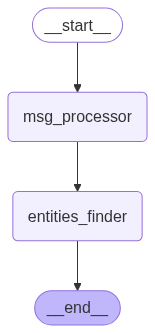

In [19]:
builder = StateGraph(ExtendedMessagesState)
builder.add_node("msg_processor", process_message_node)
builder.add_node("entities_finder", find_entities_node)
builder.add_edge(START,"msg_processor")
builder.add_edge("msg_processor","entities_finder")
builder.add_edge("entities_finder",END)
react_graph = builder.compile()
memory = MemorySaver()
react_graph_memory = builder.compile(checkpointer=memory)
react_graph


In [20]:
config = {"configurable": {"thread_id": str(uuid.uuid4())}}

In [6]:
print(df_analysis.iloc[227].content)

Remora here to Sailor Shifts. We'll need additional event staff aboard tomorrow. Davis mentioned thanking Nadia Conti personally - she called in favors at the permit office and got Commissioner Torres to sign off within hours. Unprecedented speed.


In [22]:
responses=react_graph_memory.invoke({"messages": [df_analysis.iloc[227].content]},config=config)

In [23]:
processed_text=str(responses['messages'][-1].content)

In [106]:
processed_text

"We'll need additional event staff aboard tomorrow. Davis mentioned thanking Nadia Conti personally - she called in favors at the permit office and got Commissioner Torres to sign off within hours. Unprecedented speed."

In [24]:
responses

{'messages': [HumanMessage(content="Remora here to Sailor Shifts. We'll need additional event staff aboard tomorrow. Davis mentioned thanking Nadia Conti personally - she called in favors at the permit office and got Commissioner Torres to sign off within hours. Unprecedented speed.", additional_kwargs={}, response_metadata={}, id='26e89cf7-e240-448b-8cb3-8b6a5b7245a2'),
  AIMessage(content="We'll need additional event staff aboard tomorrow. Davis mentioned thanking Nadia Conti personally - she called in favors at the permit office and got Commissioner Torres to sign off within hours. Unprecedented speed.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 183, 'total_tokens': 221, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-2025-04-14', 'sy

In [25]:
ast.literal_eval(responses['entities'].content)

['davis', 'nadia conti', 'commissioner torres', 'permit office']

## Detect Entities across the corpus of radio communications

In [122]:
all_responses=[]
resp_ids=[]
for dn,drow in df_analysis.iterrows():
    try:
        config = {"configurable": {"thread_id": str(uuid.uuid4())}}

        responses=react_graph_memory.invoke({"messages": [drow.content]},config=config)
        all_responses.append(responses)
        resp_ids.append(dn)
    except Exception as e:
        print(e)
        print(f"Error processing message {dn}")

all_responses,resp_ids

([{'messages': [HumanMessage(content="Hey The Intern, it's The Lookout! Just spotted a pod of dolphins near the eastern point this morning. They were so playful! If you're free this weekend, the migratory birds are starting to arrive too. Let me know if you want to join for some birdwatching!", additional_kwargs={}, response_metadata={}, id='423493c2-940a-467d-860b-88d984545d46'),
    AIMessage(content="Just spotted a pod of dolphins near the eastern point this morning. They were so playful! If you're free this weekend, the migratory birds are starting to arrive too. Let me know if you want to join for some birdwatching!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 193, 'total_tokens': 241, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-

ValueError: All arrays must be of the same length

In [153]:
processed_texts=[]
processed_entities=[]
for results in all_responses:
    processed_texts.append(results['messages'][-1].content)
    processed_entities.append(ast.literal_eval(results['entities'].content))

processed_texts
processed_entities


["Just spotted a pod of dolphins near the eastern point this morning. They were so playful! If you're free this weekend, the migratory birds are starting to arrive too. Let me know if you want to join for some birdwatching!",
 "I'd absolutely love to join you for birdwatching this weekend! Those dolphins sound amazing. What time were you thinking? I'll bring my new binoculars that Mrs. Money helped me pick out.",
 "Let's meet at Sunrise Point at 7 AM for birdwatching. Bring your new binoculars and some water. I've heard there might be some rare shorebirds passing through this weekend. Can't wait!",
 "Just checking in to see what tasks you need help with today. Also, I'll be birdwatching with The Lookout this weekend. Should I reschedule if you need me for anything?",
 "I've reviewed our operational funding for the upcoming projects. Need to discuss allocation priorities before our meeting with The Middleman next week. Are you available tomorrow afternoon?",
 "I'm available tomorrow at 

[['eastern point'],
 ['mrs. money'],
 ['sunrise point'],
 ['the lookout'],
 ['the middleman'],
 ['the middleman'],
 ['nemo reef'],
 ['nemo reef'],
 ['nemo reef'],
 ['marina', 'nemo reef', 'council'],
 ['marina', 'council', 'nemo reef'],
 ['nemo reef'],
 ['nemo reef', 'azure cove'],
 ['nemo reef'],
 ['remora', 'sailors team'],
 ['coral point', 'dolphin bay', 'himark'],
 ['the middleman', 'nemo reef'],
 ['nemo reef', 'boss'],
 ['nemo reef'],
 ['120-foot vessel'],
 ['the pearl', 'harbor staff'],
 ['nemo reef'],
 ['nemo reef', 'rodriguez', 'sailor shifts team'],
 ['nemo reef'],
 ['paackland harbor', 'nemo reef', 'harbor masters'],
 ['nemo reef', 'boss', 'council', 'cafe'],
 ['cafe', 'nemo reef'],
 ['nemo reef', 'harbor masters'],
 ['liam thorne'],
 ['nemo reef', 'oceanus council'],
 ['local fishermen'],
 ['oceanus city council', 'harbor services'],
 ['local fishermen'],
 ['community forum'],
 ['azure cove', 'dolphin bay', "himark's south dock"],
 ['nemo reef'],
 ['nemo reef'],
 ['nemo reef

In [154]:
text_processed_df= pd.DataFrame({"Message_ID":resp_ids,"Processed_Text":processed_texts,"Entities":processed_entities})

In [155]:
text_processed_df

,Message_ID,Processed_Text,Entities
0,0,Just spotted a pod of dolphins near the easter...,[eastern point]
1,1,I'd absolutely love to join you for birdwatchi...,[mrs. money]
2,2,Let's meet at Sunrise Point at 7 AM for birdwa...,[sunrise point]
3,3,Just checking in to see what tasks you need he...,[the lookout]
4,4,I've reviewed our operational funding for the ...,[the middleman]
...,...,...,...
575,575,Harbor closure timeline confirmed for 0600 tom...,"[harbor, delta-3, nadia, davis]"
576,576,Final confirmation: operation proceeds at 0600...,"[delta-3, conservation vessel, davis, harbor]"
577,577,What's your ETA with the additional support te...,"[delta-3, harbor entrance]"
578,578,Your access denial was per current maritime cl...,"[nemo reef, conservation vessels]"


In [157]:
df_analysis

,source_entity_action,content,timestamp,target_entity_action,date,hour,minute,time,minutes_from_day_start,time_group,time_group_sortable,source_entity_type,target_entity_type,mins_since_start_of_day,source,target,packet_id
0,sent,"Hey The Intern, it's The Lookout! Just spotted...",2040-10-01 08:09:00,received,2040-10-01,8,9,8:09:00,489,8.00am-8.15am,480,Person,Person,0,The Lookout,The Intern,1
1,sent,"Hey The Lookout, The Intern here! I'd absolute...",2040-10-01 08:10:00,received,2040-10-01,8,10,8:10:00,490,8.00am-8.15am,480,Person,Person,1,The Intern,The Lookout,1
2,sent,"Sam, it's Kelly! Let's meet at Sunrise Point a...",2040-10-01 08:13:00,received,2040-10-01,8,13,8:13:00,493,8.00am-8.15am,480,Person,Person,4,Kelly,Sam,1
3,sent,"Mrs. Money, it's The Intern. Just checking in ...",2040-10-01 08:16:00,received,2040-10-01,8,16,8:16:00,496,8.15am-8.30am,495,Person,Person,7,The Intern,Mrs. Money,1
4,sent,"Boss, it's Mrs. Money. I've reviewed our opera...",2040-10-01 08:19:00,received,2040-10-01,8,19,8:19:00,499,8.15am-8.30am,495,Person,Person,10,Mrs. Money,Boss,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
575,sent,"Green Guardians, Oceanus City Council here. Yo...",2040-10-14 12:50:00,received,2040-10-14,12,50,12:50:00,770,1.45pm-1.00pm,765,Organization,Organization,284,Oceanus City Council,Green Guardians,85
576,sent,"EcoVigil, Green Guardians HQ here. Your video ...",2040-10-14 12:51:00,received,2040-10-14,12,51,12:51:00,771,1.45pm-1.00pm,765,Organization,Vessel,285,Green Guardians,EcoVigil,85
577,sent,Defender to Mako. Be advised that conservation...,2040-10-14 13:31:00,received,2040-10-14,13,31,13:31:00,811,1.30pm-1.45pm,810,Vessel,Vessel,325,Defender,Mako,86
578,sent,"Knowles, Mako here. Proceed to southern dock a...",2040-10-14 13:34:00,received,2040-10-14,13,34,13:34:00,814,1.30pm-1.45pm,810,Vessel,Vessel,328,Mako,Knowles,86


In [130]:
df_analysis['Message_ID']=df_analysis.index

In [133]:
df_entities_processed=df_analysis.merge(text_processed_df,on="Message_ID",how="inner")

In [ ]:
df_entities_processed.drop('id',axis=1,inplace=True)
df_entities_processed.to_csv('MC3_entities_processed.csv',index=False)

In [12]:
df_entities_processed=pd.read_csv('data/MC3_entities_processed.csv')
df_entities_processed.head()

,Entities,content,Message_ID,Processed_Text
0,['eastern point'],"hey the intern, it's the lookout! just spotted...",1,just spotted a pod of dolphins near the easter...
1,['mrs. money'],"hey the lookout, the intern here! i'd absolute...",2,i'd absolutely love to join you for birdwatchi...
2,['sunrise point'],"sam, it's kelly! let's meet at sunrise point a...",3,let's meet at sunrise point at 7 am for birdwa...
3,['the lookout'],"mrs. money, it's the intern. just checking in ...",4,just checking in to see what tasks you need he...
4,['the middleman'],"boss, it's mrs. money. i've reviewed our opera...",5,i've reviewed our operational funding for the ...


In [13]:
df_entities_processed['Message_ID']=df_entities_processed.index

In [29]:
df_entities_processed.to_csv("data/MC3_comms_data_final.csv",index=False)

In [327]:
df_entities_processed.groupby('packet_id')['Message_ID'].nunique().reset_index()

,packet_id,Message_ID
0,1,11
1,2,5
2,3,5
3,4,14
4,5,1
...,...,...
81,82,3
82,83,4
83,84,7
84,85,3


In [328]:
import ast
# Flatten all entities from the 'Entities' column (which are stringified lists)
all_entities = []
for ents in df_entities_processed['Entities']:
    if isinstance(ents, str):
        try:
            ents_list = ast.literal_eval(ents)
            if isinstance(ents_list, list):
                all_entities.extend([e.strip() for e in ents_list])
        except Exception:
            continue

unique_entities = sorted(set(all_entities))
entities_df = pd.DataFrame({'Entities': unique_entities, 'mapped_entities': ['']*len(unique_entities)})

In [10]:
entities_df.to_csv("data/entity_recoinciled.csv",index=False)

## Cleaned Entities Snippet

In [329]:
cleaned_entities_df=pd.read_csv("data/entity_recoinciled.csv")

In [330]:
entities_df

,Entities,mapped_entities
0,120-foot vessel,
1,activity logs,
2,alpha-7-delta,
3,alpha-937,
4,application nr-1045,
...,...,...
279,west reef edge,
280,western boundary,
281,western perimeter,
282,western quadrant,


In [331]:
cleaned_entities_df

,Entities,mapped_entities
0,120-foot vessel,none
1,activity logs,none
2,alpha-7-delta,alpha-7-delta
3,alpha-937,alpha-937
4,application nr-1045,priority event application nr-1045
...,...,...
279,west reef edge,west nemo reef
280,western boundary,west nemo reef
281,western perimeter,west nemo reef
282,western quadrant,western quadrant


In [332]:
cdf=cleaned_entities_df.merge(entities_df.loc[:,['Entities']], on='Entities', how='inner')

In [333]:
# Create a mapping dictionary from Entities to mapped_entities
entity_map = dict(zip(cleaned_entities_df['Entities'], cleaned_entities_df['mapped_entities']))

def map_entities(entity_list):
    # Map each entity using the dictionary, filter out 'None' and empty/NaN values
    mapped = []
    for e in entity_list:
        mapped_val = entity_map.get(e, None)
        # Accept if mapped_val is not 'None', not None, and not empty string
        if pd.notna(mapped_val) and str(mapped_val).lower() != 'none' and str(mapped_val).strip() != '':
            mapped.append(mapped_val)
    return mapped

# Update the 'Entities' column in df_entities_processed
import ast
df_entities_processed['Entities'] = df_entities_processed['Entities'].apply(
    lambda ents: map_entities(ast.literal_eval(ents)) if isinstance(ents, str) else []
)

df_entities_processed['Entities']

0                                      []
1                            [mrs. money]
2                         [sunrise point]
3                           [the lookout]
4                         [the middleman]
                      ...                
575    [oceanus environmental department]
576     [nemo reef, oceanus city council]
577            [reef guardian, nemo reef]
578    [himark's south dock, boss, davis]
579           [mako, himark's south dock]
Name: Entities, Length: 580, dtype: object

In [334]:
df_entities_processed

,source_entity_action,content,timestamp,target_entity_action,date,hour,minute,time,minutes_from_day_start,time_group,...,source_entity_type,target_entity_type,mins_since_start_of_day,source,target,packet_id,check,Message_ID,Processed_Text,Entities
0,sent,"Hey The Intern, it's The Lookout! Just spotted a pod of dolphins near the eastern point this morning. They were so playful! If you're free this weekend, the migratory birds are starting to arrive too. Let me know if you want to join for some birdwatching!",01/10/40 8:09,received,10/01/40,8,9,8:09:00,489,8.00am-8.15am,...,Person,Person,0,The Lookout,The Intern,1,False,0,"Just spotted a pod of dolphins near the eastern point this morning. They were so playful! If you're free this weekend, the migratory birds are starting to arrive too. Let me know if you want to join for some birdwatching!",[]
1,sent,"Hey The Lookout, The Intern here! I'd absolutely love to join you for birdwatching this weekend! Those dolphins sound amazing. What time were you thinking? I'll bring my new binoculars that Mrs. Money helped me pick out.",01/10/40 8:10,received,10/01/40,8,10,8:10:00,490,8.00am-8.15am,...,Person,Person,1,The Intern,The Lookout,1,False,1,I'd absolutely love to join you for birdwatching this weekend! Those dolphins sound amazing. What time were you thinking? I'll bring my new binoculars that Mrs. Money helped me pick out.,[mrs. money]
2,sent,"Sam, it's Kelly! Let's meet at Sunrise Point at 7 AM for birdwatching. Bring your new binoculars and some water. I've heard there might be some rare shorebirds passing through this weekend. Can't wait!",01/10/40 8:13,received,10/01/40,8,13,8:13:00,493,8.00am-8.15am,...,Person,Person,4,Kelly,Sam,1,False,2,Let's meet at Sunrise Point at 7 AM for birdwatching. Bring your new binoculars and some water. I've heard there might be some rare shorebirds passing through this weekend. Can't wait!,[sunrise point]
3,sent,"Mrs. Money, it's The Intern. Just checking in to see what tasks you need help with today. Also, I'll be birdwatching with The Lookout this weekend. Should I reschedule if you need me for anything?",01/10/40 8:16,received,10/01/40,8,16,8:16:00,496,8.15am-8.30am,...,Person,Person,7,The Intern,Mrs. Money,1,False,3,"Just checking in to see what tasks you need help with today. Also, I'll be birdwatching with The Lookout this weekend. Should I reschedule if you need me for anything?",[the lookout]
4,sent,"Boss, it's Mrs. Money. I've reviewed our operational funding for the upcoming projects. Need to discuss allocation priorities before our meeting with The Middleman next week. Are you available tomorrow afternoon?",01/10/40 8:19,received,10/01/40,8,19,8:19:00,499,8.15am-8.30am,...,Person,Person,10,Mrs. Money,Boss,1,False,4,I've reviewed our operational funding for the upcoming projects. Need to discuss allocation priorities before our meeting with The Middleman next week. Are you available tomorrow afternoon?,[the middleman]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
575,sent,"Green Guardians, Oceanus City Council here. Your emergency session request is denied. Our environmental review team requires 72 hours to properly assess your claims. Legal threats will not expedite this process. Submit documentation through official channels.",14/10/40 12:50,received,14/10/40,12,50,12:50:00,770,1.45pm-1.00pm,...,Organization,Organization,284,Oceanus City Council,Green Guardians,85,False,575,Your emergency session request is denied. Our environmental review team requires 72 hours to properly assess your claims. Legal threats will not expedite this process. Submit documentation through official channels.,[oceanus environmental department]
576,sent,"EcoVigil, Green Guardians HQ here. Your video evidence has been invaluable. Please continue monitoring Nemo Reef for environmental impacts. Document any cleanup efforts or lack thereof as vessels depart. We're building a case for regulatory action despite Council delays.

In [335]:
df_entities_processed.to_csv("data/MC3_comms_data_final.csv",index=False)

In [311]:
df_pseudonyms=df_entities_processed.iloc[:40].loc[:,['source','target','content','Message_ID','packet_id']]

In [45]:
# For each packet, filter messages where the source and target have not reciprocated to each other

def filter_nonreciprocated(df):
    filtered = []
    for packet_id, group in df.groupby('packet_id'):
        # Build set of (source, target) and (target, source) pairs
        pairs = set(zip(group['source'], group['target']))
        reciprocated = set()
        for src, tgt in pairs:
            if (tgt, src) in pairs:
                reciprocated.add((src, tgt))
                reciprocated.add((tgt, src))
        # Keep only non-reciprocated messages
        mask = ~group[['source', 'target']].apply(tuple, axis=1).isin(reciprocated)
        filtered.append(group[mask])
    return pd.concat(filtered, ignore_index=True)

df_nonreciprocated = filter_nonreciprocated(df_pseudonyms)
df_nonreciprocated

,source,target,content,Message_ID,packet_id
0,Kelly,Sam,"Sam, it's Kelly! Let's meet at Sunrise Point at 7 AM for birdwatching. Bring your new binoculars and some water. I've heard there might be some rare shorebirds passing through this weekend. Can't wait!",2,1
1,The Intern,Mrs. Money,"Mrs. Money, it's The Intern. Just checking in to see what tasks you need help with today. Also, I'll be birdwatching with The Lookout this weekend. Should I reschedule if you need me for anything?",3,1
2,Serenity,Reef Guardian,"Reef Guardian, this is Serenity. My owner is quite disappointed about Nemo Reef restrictions. Are there any special permits available for private vessels to access certain sections? We're willing to follow strict conservation guidelines.",13,2
3,Himark Harbor,Mako,Harbor Master to Mako. Confirming your 07:00 departure today with Remora for Sailors Team's reconnaissance. Please remember to return before sunset and maintain distance from protected marine areas. Safe journey.,14,2
4,Mako,Davis,"Davis, Mako here. Just completed documentation of our sites. Coral Point has excellent visibility but too exposed for filming. Dolphin Bay offers privacy but those currents will be challenging for equipment setup. Heading back to Himark as scheduled.",15,2
5,Boss,Mrs. Money,"Mrs. Money, this is Boss. After speaking with The Middleman, I'm confident about our Nemo Reef opportunity. He mentioned a potential loophole in protection zones. Let's discuss this during our 3PM meeting along with funding allocations.",16,3
6,Mrs. Money,The Middleman,"Middleman, it's Mrs. Money. I've prepared those financial projections we discussed. Particularly interested in your thoughts on that Nemo Reef loophole before my meeting with Boss tomorrow. Available to talk this evening?",17,3
7,Reef Guardian,Serenity,"Serenity, Reef Guardian here. I understand your disappointment, but Nemo Reef is strictly protected without special access permits. However, we can recommend several equally beautiful non-protected areas nearby. We're observing increased tourism pressure lately, which is why enforcement remains strict.",18,3
8,Paackland Harbor,Reef Guardian,"Reef Guardian, Paackland Harbor here. We're seeing increased tourism activity near Nemo Reef's protected zones. Please increase monitoring patrols in that area over the next 48 hours. Oceanus Council is adding signage tomorrow. Confirm when possible.",29,4
9,Mako,Remora,Mako to Remora. How's visibility in your sector? We've documented good conditions at Azure Cove and challenging currents at Dolphin Bay. Planning to rendezvous at Himark's south dock at 16:00 as scheduled. Over.,34,4


In [ ]:
pseudonym_prompt = textwrap.dedent(
"""
You are a helpful assistant that can identify pseudonyms in a conversation.

You will be given a conversation between two people.

You will need to identify the pseudonyms in the conversation.

You will need to return the pseudonyms in a list. If there are no pseudonyms, return an empty list.

Example for pseudonyms:
Message 1: Hey The Lookout, The Intern here! I'd absolutely love to join you for birdwatching this weekend! Those dolphins sound amazing. What time were you thinking? I'll bring my new binoculars that Mrs. Money helped me pick out.
Message 2: Sam, it's Kelly! Let's meet at Sunrise Point at 7 AM for birdwatching. Bring your new binoculars and some water. I've heard there might be some rare shorebirds passing through this weekend. Can't wait!

Here, there is a potential pseudonym for the Intern, which is 'Sam'. 


Input is of the form Message 1 (ID {msg_i}), From: {src_i},  To: {tgt_i}, Content: {content_i}
Message 2 (ID {msg_j}), From: {src_j},  To: {tgt_j}, Content: {content_j}


"""
)

In [46]:
# # --- Message Embedding Creation and Visualization ---

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.decomposition import PCA
# from sklearn.manifold import TSNE

# # If you have openai embeddings, use them; otherwise, fallback to sentence-transformers
# try:
#     import openai
#     use_openai = True
# except ImportError:
#     use_openai = False

# # Optionally, use sentence-transformers for local embedding
# try:
#     from sentence_transformers import SentenceTransformer
#     st_model = SentenceTransformer('all-MiniLM-L6-v2')
#     use_st = True
# except ImportError:
#     use_st = False

# # Get message contents and IDs
# contents = df_pseudonyms['content'].tolist()
# message_ids = df_pseudonyms['Message_ID'].tolist()

# # Compute embeddings
# embeddings = []
# if use_openai:
#     # Use OpenAI embeddings API (e.g., text-embedding-3-small)
#     for text in contents:
#         try:
#             response = openai.embeddings.create(
#                 input=text,
#                 model="text-embedding-3-small"
#             )
#             emb = response.data[0].embedding
#         except Exception as e:
#             emb = [np.nan] * 1536  # or appropriate size
#         embeddings.append(emb)
# elif use_st:
#     # Use sentence-transformers locally
#     embeddings = st_model.encode(contents, show_progress_bar=True)
# else:
#     raise ImportError("No embedding model available. Please install openai or sentence-transformers.")

# embeddings = np.array(embeddings)
 
#  # Dimensionality reduction (PCA, then t-SNE for visualization)
# # Fix: n_components for PCA must be <= min(n_samples, n_features)
# n_samples, n_features = embeddings.shape
# pca_components = min(50, n_samples, n_features)
# if n_features > pca_components:
#     pca = PCA(n_components=pca_components, random_state=42)
#     reduced = pca.fit_transform(embeddings)
# else:
#     reduced = embeddings

# tsne = TSNE(n_components=2, random_state=42, perplexity=30)
# emb_2d = tsne.fit_transform(reduced)

# # Plot
# plt.figure(figsize=(10, 8))
# plt.scatter(emb_2d[:, 0], emb_2d[:, 1], alpha=0.7)

# # Annotate with message IDs
# for i, msg_id in enumerate(message_ids):
#     plt.annotate(str(msg_id), (emb_2d[i, 0], emb_2d[i, 1]), fontsize=8, alpha=0.7)

# plt.title("Message Embeddings Visualization (t-SNE)")
# plt.xlabel("Dimension 1")
# plt.ylabel("Dimension 2")
# plt.tight_layout()
# plt.show()


#  # Dimensionality reduction (PCA, then t-SNE for visualization)
# # Fix: n_components for PCA must be <= min(n_samples, n_features)
# n_samples, n_features = embeddings.shape
# pca_components = min(50, n_samples, n_features)
# if n_features > pca_components:
#     pca = PCA(n_components=pca_components, random_state=42)
#     reduced = pca.fit_transform(embeddings)
# else:
#     reduced = embeddings

# tsne = TSNE(n_components=2, random_state=42, perplexity=30)
# emb_2d = tsne.fit_transform(reduced)

# # Plot
# plt.figure(figsize=(10, 8))
# plt.scatter(emb_2d[:, 0], emb_2d[:, 1], alpha=0.7)

# # Annotate with message IDs
# for i, msg_id in enumerate(message_ids):
#     plt.annotate(str(msg_id), (emb_2d[i, 0], emb_2d[i, 1]), fontsize=8, alpha=0.7)

# plt.title("Message Embeddings Visualization (t-SNE)")
# plt.xlabel("Dimension 1")
# plt.ylabel("Dimension 2")
# plt.tight_layout()
# plt.show()



ValueError: n_components=50 must be between 0 and min(n_samples, n_features)=40 with svd_solver='full'

In [25]:
df_entities_processed=pd.read_csv("data/MC3_data_no_pseudonyms.csv")
df_entities_processed.head()

,content,timestamp,date,timeblock,source_entity_type,target_entity_type,source,target,hour,time,mins_since_start_of_day,packet_id,Message_ID,Processed_Text,Entities
0,"hey the intern, it's the lookout! just spotted...",2040-10-01 08:09:00,2040-10-01,8:15,Person,Person,the lookout,the intern,8,08:09:00,0,1,1,just spotted a pod of dolphins near the easter...,[]
1,"hey the lookout, the intern here! i'd absolute...",2040-10-01 08:10:00,2040-10-01,8:15,Person,Person,the intern,the lookout,8,08:10:00,1,1,2,i'd absolutely love to join you for birdwatchi...,['mrs. money']
2,"sam, it's kelly! let's meet at sunrise point a...",2040-10-01 08:13:00,2040-10-01,8:15,Person,Person,kelly,sam,8,08:13:00,4,1,3,let's meet at sunrise point at 7 am for birdwa...,['sunrise point']
3,"mrs. money, it's the intern. just checking in ...",2040-10-01 08:16:00,2040-10-01,8:30,Person,Person,the intern,mrs. money,8,08:16:00,7,1,4,just checking in to see what tasks you need he...,['the lookout']
4,"boss, it's mrs. money. i've reviewed our opera...",2040-10-01 08:19:00,2040-10-01,8:30,Person,Person,mrs. money,boss,8,08:19:00,10,1,5,i've reviewed our operational funding for the ...,['the middleman']


# Compute embeddings for all communications

Computing embeddings for 580 messages...
Processed 50/580 messages
Processed 100/580 messages
Processed 150/580 messages
Processed 200/580 messages
Processed 250/580 messages
Processed 300/580 messages
Processed 350/580 messages
Processed 400/580 messages
Processed 450/580 messages
Processed 500/580 messages
Processed 550/580 messages
Embeddings shape: (580, 1536)
Reducing dimensions from 1536 to 50 using PCA...
Applying t-SNE for 2D visualization...


<Figure size 1500x1200 with 0 Axes>

Text(22.83152961730957, 22.855911254882812, '1')

Text(-16.637161254882812, 10.892560958862305, '11')

Text(22.89628791809082, -15.462506294250488, '21')

...

Text(-13.000895500183105, 35.1888313293457, '561')

Text(9.365062713623047, -27.88027000427246, '571')

Text(0.5, 1.0, 'Message Embeddings Visualization (t-SNE) - All 580 Messages')

Text(0.5, 0, 'Dimension 1')

Text(0, 0.5, 'Dimension 2')

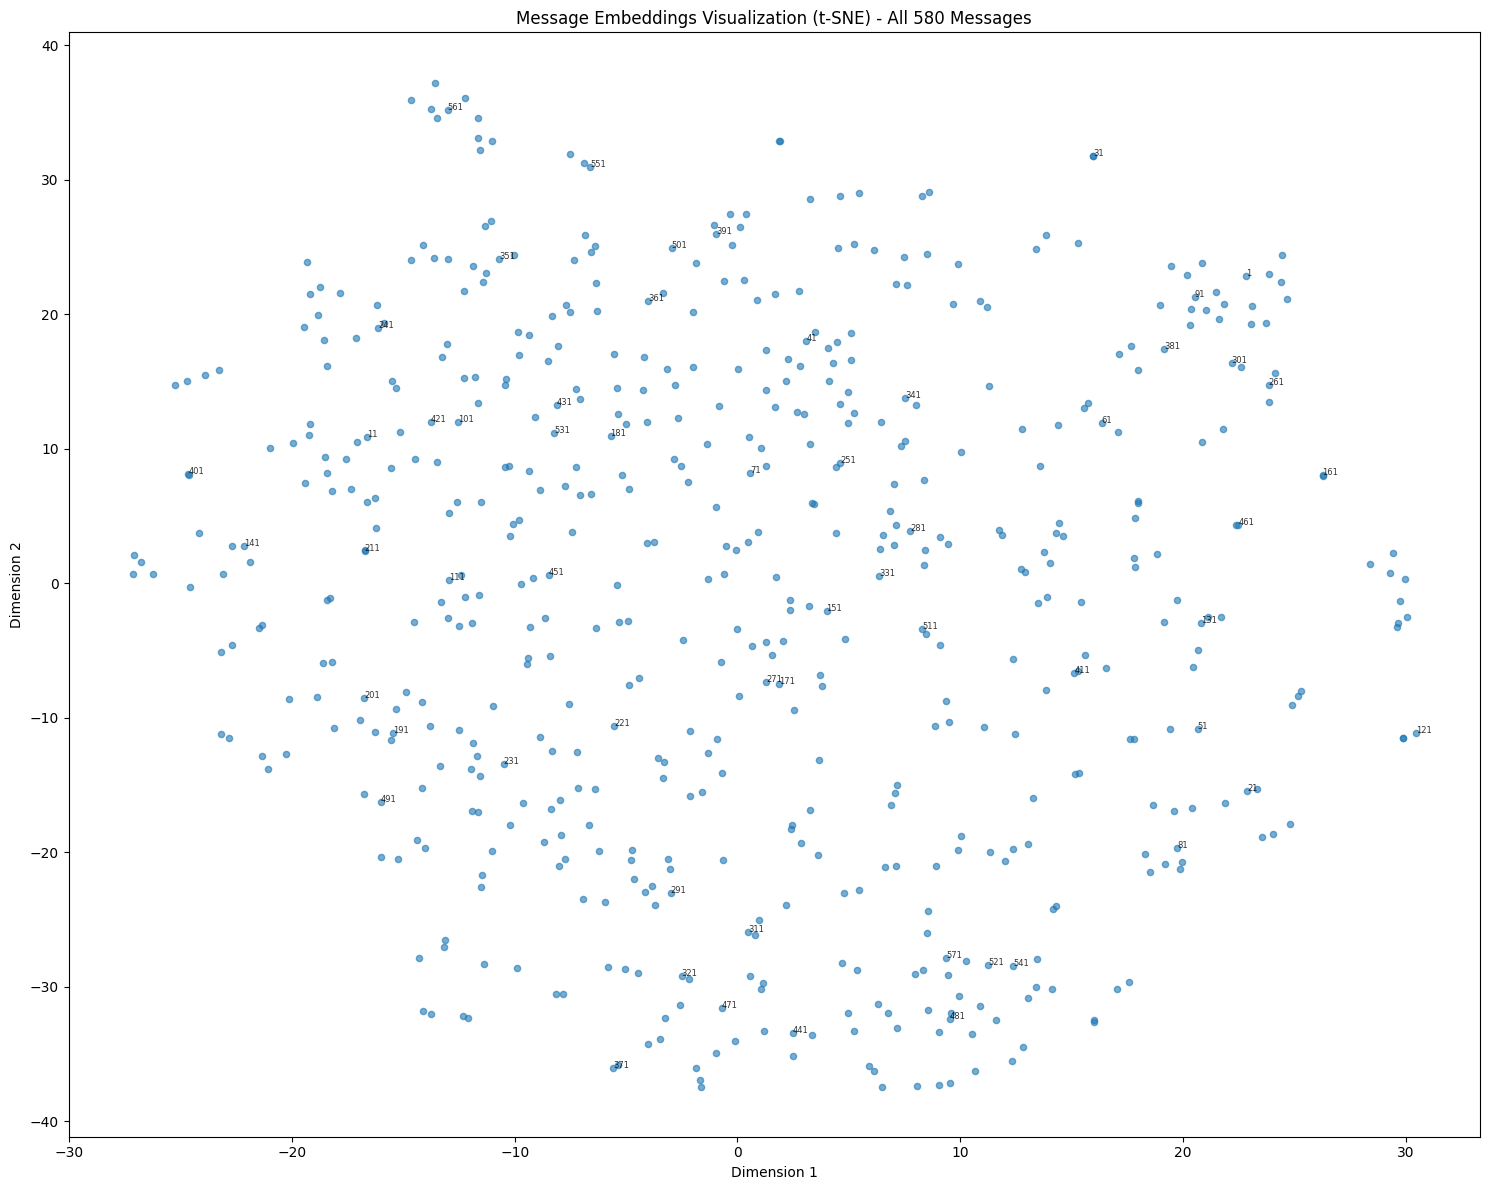

Saving embeddings to file...
Embeddings saved to 'data/message_embeddings.csv'

Embedding Statistics:
Total messages processed: 580
Embedding dimensions: 1536
PCA components used: 50
t-SNE perplexity used: 30


<Figure size 1500x1200 with 0 Axes>

Text(0.5, 1.0, 'Message Embeddings by Packet ID - All 580 Messages')

Text(0.5, 0, 'Dimension 1')

Text(0, 0.5, 'Dimension 2')

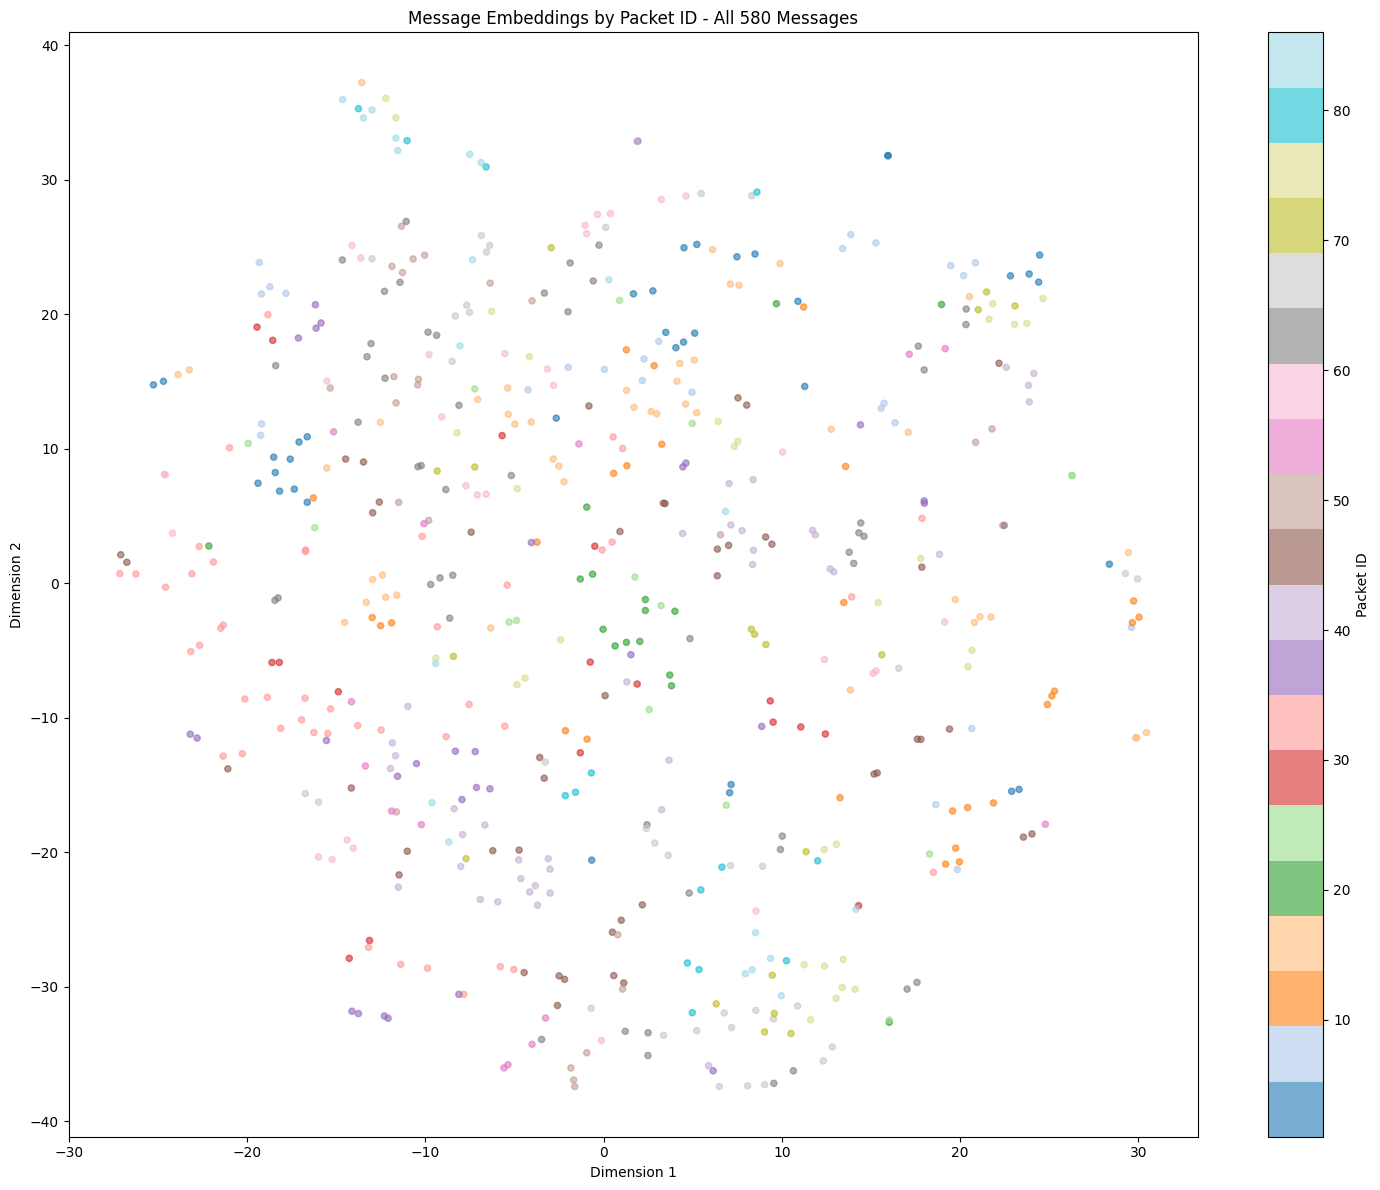

<Figure size 1500x1200 with 0 Axes>

Text(0.5, 1.0, 'Message Embeddings by Source - All 580 Messages')

Text(0.5, 0, 'Dimension 1')

Text(0, 0.5, 'Dimension 2')

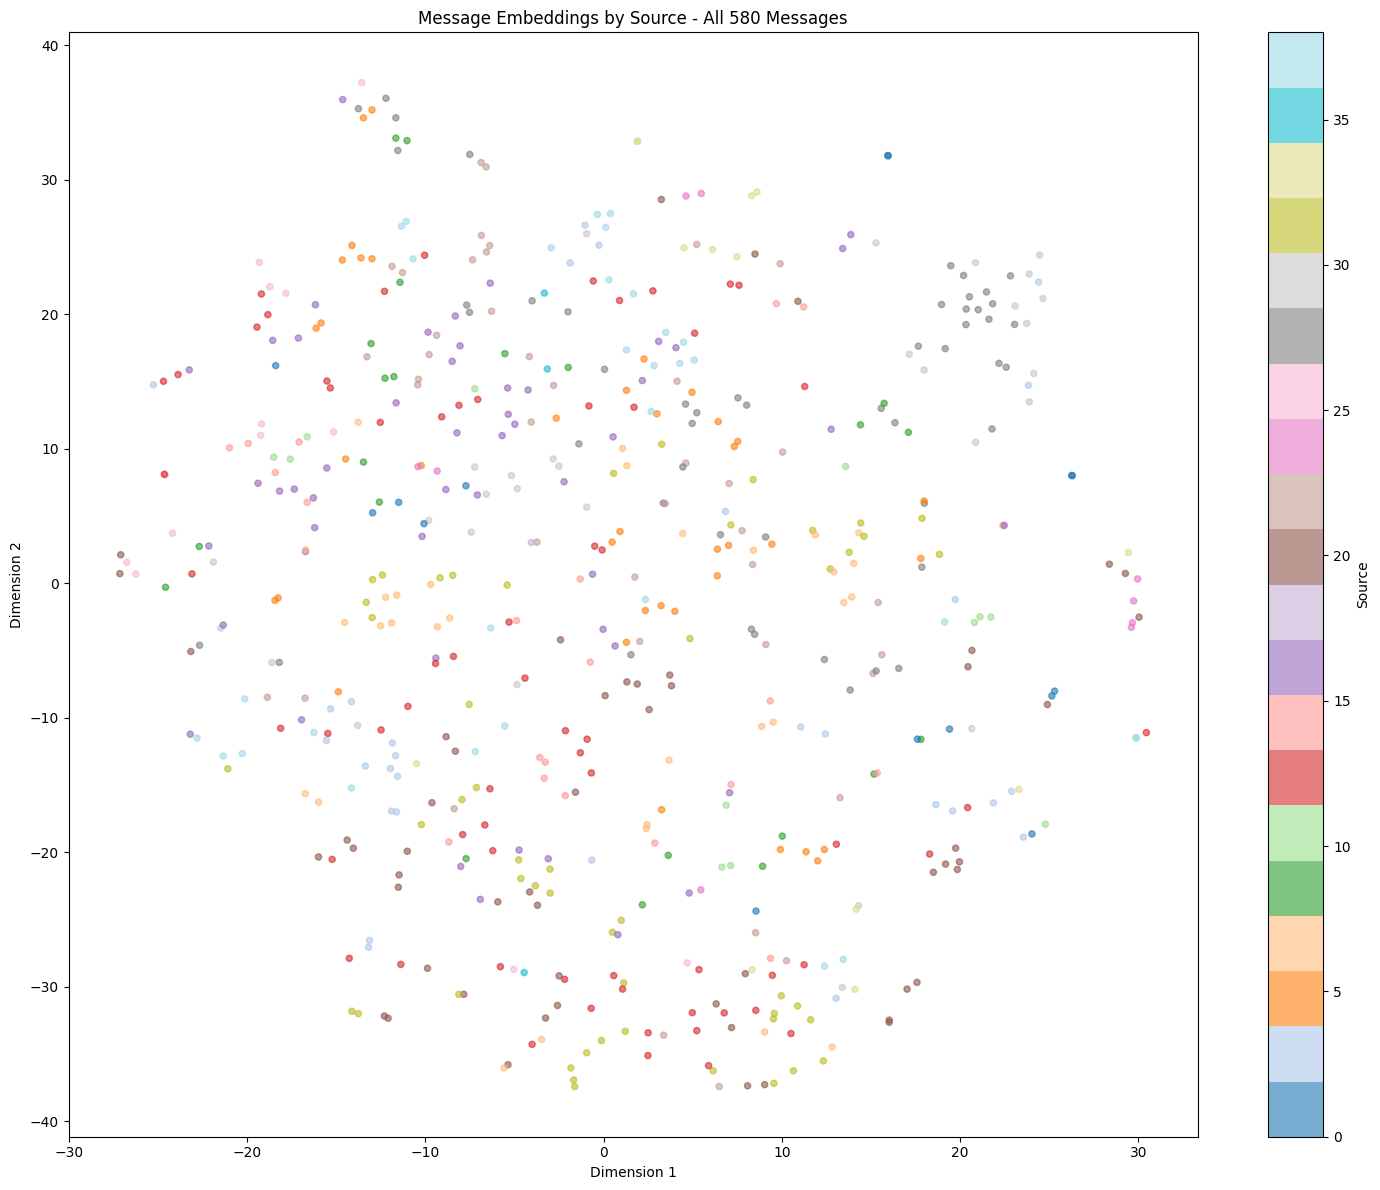

In [26]:
# --- Message Embedding Creation and Visualization for All 580 Sentences ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# If you have openai embeddings, use them; otherwise, fallback to sentence-transformers
try:
    import openai
    use_openai = True
except ImportError:
    use_openai = False

# Optionally, use sentence-transformers for local embedding
try:
    from sentence_transformers import SentenceTransformer
    st_model = SentenceTransformer('all-MiniLM-L6-v2')
    use_st = True
except ImportError:
    use_st = False

# Get all message contents and IDs from the full dataframe (all 580 sentences)
# Change df_pseudonyms to df_entities_processed to use all messages
contents = df_entities_processed['Processed_Text'].tolist()
message_ids = df_entities_processed['Message_ID'].tolist()

print(f"Computing embeddings for {len(contents)} messages...")

# Compute embeddings
embeddings = []
if use_openai:
    # Use OpenAI embeddings API (e.g., text-embedding-3-small)
    for i, text in enumerate(contents):
        try:
            response = openai.embeddings.create(
                input=text,
                model="text-embedding-3-small"
            )
            emb = response.data[0].embedding
            embeddings.append(emb)
            if (i + 1) % 50 == 0:
                print(f"Processed {i + 1}/{len(contents)} messages")
        except Exception as e:
            print(f"Error processing message {i}: {e}")
            emb = [np.nan] * 1536  # or appropriate size
            embeddings.append(emb)
elif use_st:
    # Use sentence-transformers locally
    print("Computing embeddings using sentence-transformers...")
    embeddings = st_model.encode(contents, show_progress_bar=True)
else:
    raise ImportError("No embedding model available. Please install openai or sentence-transformers.")

embeddings = np.array(embeddings)
print(f"Embeddings shape: {embeddings.shape}")

# Dimensionality reduction (PCA, then t-SNE for visualization)
# Fix: n_components for PCA must be <= min(n_samples, n_features)
n_samples, n_features = embeddings.shape
pca_components = min(50, n_samples, n_features)
if n_features > pca_components:
    print(f"Reducing dimensions from {n_features} to {pca_components} using PCA...")
    pca = PCA(n_components=pca_components, random_state=42)
    reduced = pca.fit_transform(embeddings)
else:
    reduced = embeddings

print("Applying t-SNE for 2D visualization...")
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(contents)//4))
emb_2d = tsne.fit_transform(reduced)

# Plot
plt.figure(figsize=(15, 12))
plt.scatter(emb_2d[:, 0], emb_2d[:, 1], alpha=0.6, s=20)

# Annotate with message IDs (only show some to avoid clutter)
# Show every 10th message ID to avoid overcrowding
for i in range(0, len(message_ids), 10):
    plt.annotate(str(message_ids[i]), (emb_2d[i, 0], emb_2d[i, 1]), 
                fontsize=6, alpha=0.8)

plt.title(f"Message Embeddings Visualization (t-SNE) - All {len(contents)} Messages")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.tight_layout()
plt.show()

# Save embeddings to file for later use
embedding_df = pd.DataFrame({
    'Message_ID': message_ids,
    'embedding': [emb.tolist() for emb in embeddings]
})

# Also save the 2D coordinates for visualization
embedding_df['tsne_x'] = emb_2d[:, 0]
embedding_df['tsne_y'] = emb_2d[:, 1]

print("Saving embeddings to file...")
embedding_df.to_csv('data/message_embeddings.csv', index=False)
print("Embeddings saved to 'data/message_embeddings.csv'")

# Display some statistics 
print(f"\nEmbedding Statistics:")
print(f"Total messages processed: {len(contents)}")
print(f"Embedding dimensions: {embeddings.shape[1]}")
print(f"PCA components used: {pca_components}")
print(f"t-SNE perplexity used: {min(30, len(contents)//4)}")

# Optional: Create additional visualizations
# 1. Embeddings colored by packet_id
if 'packet_id' in df_entities_processed.columns:
    packet_ids = df_entities_processed['packet_id'].tolist()
    plt.figure(figsize=(15, 12))
    scatter = plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=packet_ids, alpha=0.6, s=20, cmap='tab20')
    plt.colorbar(scatter, label='Packet ID')
    plt.title(f"Message Embeddings by Packet ID - All {len(contents)} Messages")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.tight_layout()
    plt.show()

# 2. Embeddings colored by source
if 'source' in df_entities_processed.columns:
    sources = df_entities_processed['source'].tolist()
    unique_sources = list(set(sources))
    source_to_num = {src: i for i, src in enumerate(unique_sources)}
    source_nums = [source_to_num[src] for src in sources]
    
    plt.figure(figsize=(15, 12))
    scatter = plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=source_nums, alpha=0.6, s=20, cmap='tab20')
    plt.colorbar(scatter, label='Source')
    plt.title(f"Message Embeddings by Source - All {len(contents)} Messages")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.tight_layout()
    plt.show()

In [27]:
embedding_df

,Message_ID,embedding,tsne_x,tsne_y
0,1,"[0.02055405080318451, 0.04590366408228874, 0.0...",22.831530,22.855911
1,2,"[0.04030311107635498, 0.009800927713513374, -0...",23.881544,22.990398
2,3,"[0.02411470003426075, 0.04252433031797409, 0.0...",24.412205,22.387178
3,4,"[-0.005292892921715975, 0.0354364812374115, 0....",24.470757,24.402426
4,5,"[-0.026536017656326294, 0.035924412310123444, ...",7.069335,-15.568633
...,...,...,...,...
575,576,"[0.01044132187962532, 0.04764419049024582, 0.0...",-9.434031,-5.963329
576,577,"[0.0733649879693985, 0.050644975155591965, 0.0...",-8.058951,17.651545
577,578,"[0.07221478968858719, 0.05554574355483055, 0.0...",0.295960,22.560999
578,579,"[0.058435261249542236, 0.032033421099185944, 0...",7.950613,-29.019655


In [28]:
embedding_df=pd.read_csv("data/message_embeddings.csv")

In [29]:
embedding_df

,Message_ID,embedding,tsne_x,tsne_y
0,1,"[0.02055405080318451, 0.04590366408228874, 0.0...",22.831530,22.855911
1,2,"[0.04030311107635498, 0.009800927713513374, -0...",23.881544,22.990398
2,3,"[0.02411470003426075, 0.04252433031797409, 0.0...",24.412205,22.387178
3,4,"[-0.005292892921715975, 0.0354364812374115, 0....",24.470757,24.402426
4,5,"[-0.026536017656326294, 0.035924412310123444, ...",7.069336,-15.568633
...,...,...,...,...
575,576,"[0.01044132187962532, 0.04764419049024582, 0.0...",-9.434031,-5.963329
576,577,"[0.0733649879693985, 0.050644975155591965, 0.0...",-8.058951,17.651545
577,578,"[0.07221478968858719, 0.05554574355483055, 0.0...",0.295960,22.560999
578,579,"[0.058435261249542236, 0.032033421099185944, 0...",7.950613,-29.019655


In [30]:
embeddings.shape

(580, 1536)

In [31]:
embeddings[1].shape

(1536,)

In [47]:
qa_pairs=df_entities_processed.iloc[:40].loc[:,['Message_ID','Processed_Text']]

In [48]:
qa_pairs['Message_ID'].tolist()

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40]

In [164]:
# qa_pairs['Processed_Text'].tolist()

In [50]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Compute cosine similarity matrix for the first 10 embeddings (corresponding to qa_pairs)
similarity_matrix = cosine_similarity(embeddings[:40])

# Identify pairs with cosine similarity >= 0.6 (excluding self-pairs)
threshold = 0.6
qa_pair_info = []
for i in range(similarity_matrix.shape[0]):
    for j in range(i+1, similarity_matrix.shape[1]):
        if similarity_matrix[i, j] >= threshold:
            source = qa_pairs.iloc[i]['Message_ID']
            target = qa_pairs.iloc[j]['Message_ID']
            potential_question = qa_pairs.iloc[i]['Processed_Text']
            potential_answer = qa_pairs.iloc[j]['Processed_Text']
            qa_pair_info.append({
                'source_message_id': source,
                'target_message_id': target,
                'potential_question': potential_question,
                'potential_answer': potential_answer,
                'similarity': similarity_matrix[i, j]
            })

# Display the pairs with their question and answer texts
for pair in qa_pair_info:
    print(f"Source Message ID: {pair['source_message_id']}")
    print(f"Target Message ID: {pair['target_message_id']}")
    print(f"Potential Question: {pair['potential_question']}")
    print(f"Potential Answer: {pair['potential_answer']}")
    print(f"Cosine Similarity: {pair['similarity']:.2f}")
    print("-" * 60)


Source Message ID: 1
Target Message ID: 2
Potential Question: just spotted a pod of dolphins near the eastern point this morning. they were so playful! if you're free this weekend, the migratory birds are starting to arrive too. let me know if you want to join for some birdwatching!
Potential Answer: i'd absolutely love to join you for birdwatching this weekend! those dolphins sound amazing. what time were you thinking? i'll bring my new binoculars that mrs. money helped me pick out.
Cosine Similarity: 0.68
------------------------------------------------------------
Source Message ID: 1
Target Message ID: 3
Potential Question: just spotted a pod of dolphins near the eastern point this morning. they were so playful! if you're free this weekend, the migratory birds are starting to arrive too. let me know if you want to join for some birdwatching!
Potential Answer: let's meet at sunrise point at 7 am for birdwatching. bring your new binoculars and some water. i've heard there might be so

In [51]:
qa_pair_df=pd.DataFrame(qa_pair_info)

In [ ]:
qa_pair_df

,source_message_id,target_message_id,potential_question,potential_answer,similarity
0,1,2,just spotted a pod of dolphins near the easter...,i'd absolutely love to join you for birdwatchi...,0.681825
1,1,3,just spotted a pod of dolphins near the easter...,let's meet at sunrise point at 7 am for birdwa...,0.610072
2,2,3,i'd absolutely love to join you for birdwatchi...,let's meet at sunrise point at 7 am for birdwa...,0.643317
3,5,6,i've reviewed our operational funding for the ...,i'm available tomorrow at 3 pm to discuss fund...,0.768837
4,5,18,i've reviewed our operational funding for the ...,i've prepared those financial projections we d...,0.636035
...,...,...,...,...,...
132,37,38,i've prepared the initial event coordination o...,confirming nemo reef as primary location. need...,0.653934
133,37,39,i've prepared the initial event coordination o...,submitting a permit application for a music vi...,0.719582
134,38,39,confirming nemo reef as primary location. need...,submitting a permit application for a music vi...,0.744049
135,38,40,confirming nemo reef as primary location. need...,while patrolling western boundary of protected...,0.671837


In [53]:
# Combine source and target entities, lower case, and add entity type
source_entities = df_entities_processed[['source', 'source_entity_type']].rename(
    columns={'source': 'entity', 'source_entity_type': 'entity_type'}
)
target_entities = df_entities_processed[['target', 'target_entity_type']].rename(
    columns={'target': 'entity', 'target_entity_type': 'entity_type'}
)

# Concatenate, lower case, drop duplicates
all_entities = pd.concat([source_entities, target_entities], ignore_index=True)
all_entities['entity'] = all_entities['entity'].str.lower()

# Drop duplicates (entity, entity_type) pairs
unique_entities = all_entities.drop_duplicates().reset_index(drop=True)

unique_entities

,entity,entity_type
0,the lookout,Person
1,the intern,Person
2,kelly,Person
3,mrs. money,Person
4,boss,Person
5,the middleman,Person
6,serenity,Vessel
7,mako,Vessel
8,himark harbor,Location
9,reef guardian,Vessel


In [ ]:
# unique_entities.to_csv("data/unique_entities.csv",index=False)

In [55]:
# Create lookup dictionary from df_entities_processed
id_to_pair = df_entities_processed.set_index("Message_ID")[["source", "target"]].to_dict("index")

# Define a function to check if a row is a reciprocal message
def is_reciprocal(row):
    src_id = row["source_message_id"]
    tgt_id = row["target_message_id"]
    
    if src_id in id_to_pair and tgt_id in id_to_pair:
        src_pair = id_to_pair[src_id]
        tgt_pair = id_to_pair[tgt_id]
        return (
            src_pair["source"] == tgt_pair["target"] and
            src_pair["target"] == tgt_pair["source"]
        )
    return False  # Treat incomplete data as non-reciprocal

# Apply filter to keep only non-reciprocal pairs
qa_pair_df_filtered = qa_pair_df[~qa_pair_df.apply(is_reciprocal, axis=1)].reset_index(drop=True)

In [56]:
qa_pair_df_filtered

,source_message_id,target_message_id,potential_question,potential_answer,similarity
0,1,3,just spotted a pod of dolphins near the easter...,let's meet at sunrise point at 7 am for birdwa...,0.610072
1,2,3,i'd absolutely love to join you for birdwatchi...,let's meet at sunrise point at 7 am for birdwa...,0.643317
2,5,18,i've reviewed our operational funding for the ...,i've prepared those financial projections we d...,0.636035
3,6,8,i'm available tomorrow at 3 pm to discuss fund...,i'd like to move our meeting forward to discus...,0.600753
4,6,10,i'm available tomorrow at 3 pm to discuss fund...,let's meet tomorrow at 4pm at the usual spot b...,0.626498
...,...,...,...,...,...
117,37,38,i've prepared the initial event coordination o...,confirming nemo reef as primary location. need...,0.653934
118,37,39,i've prepared the initial event coordination o...,submitting a permit application for a music vi...,0.719582
119,38,39,confirming nemo reef as primary location. need...,submitting a permit application for a music vi...,0.744049
120,38,40,confirming nemo reef as primary location. need...,while patrolling western boundary of protected...,0.671837


In [57]:
qa_pair_df_filtered.head(20)

,source_message_id,target_message_id,potential_question,potential_answer,similarity
0,1,3,just spotted a pod of dolphins near the easter...,let's meet at sunrise point at 7 am for birdwa...,0.610072
1,2,3,i'd absolutely love to join you for birdwatchi...,let's meet at sunrise point at 7 am for birdwa...,0.643317
2,5,18,i've reviewed our operational funding for the ...,i've prepared those financial projections we d...,0.636035
3,6,8,i'm available tomorrow at 3 pm to discuss fund...,i'd like to move our meeting forward to discus...,0.600753
4,6,10,i'm available tomorrow at 3 pm to discuss fund...,let's meet tomorrow at 4pm at the usual spot b...,0.626498
5,6,17,i'm available tomorrow at 3 pm to discuss fund...,"after speaking with the middleman, i'm confide...",0.615711
6,6,18,i'm available tomorrow at 3 pm to discuss fund...,i've prepared those financial projections we d...,0.636516
7,6,27,i'm available tomorrow at 3 pm to discuss fund...,7pm at the cafe works perfectly. i'll bring th...,0.616549
8,7,8,i'll bring the updated projections for tomorro...,i'd like to move our meeting forward to discus...,0.690965
9,7,9,i'll bring the updated projections for tomorro...,i can meet earlier as requested. nemo reef dis...,0.701619


In [58]:
# potential_questions=qa_pair_df_filtered['potential_question'].tolist()
# potential_answers=qa_pair_df_filtered['potential_answer'].tolist()
# potential_question_ids=qa_pair_df_filtered['source_message_id'].tolist()
# potential_answer_ids=qa_pair_df_filtered['target_message_id'].tolist()

In [59]:
# Build row-by-row pair strings instead of two lists
paired_examples = "\n\n".join([
    f"{qid} ➝ {aid}:\nQ: {q}\nA: {a}"
    for qid, aid, q, a in zip(
        qa_pair_df_filtered["source_message_id"],
        qa_pair_df_filtered["target_message_id"],
        qa_pair_df_filtered["potential_question"],
        qa_pair_df_filtered["potential_answer"]
    )
])

pseudonym_prompt = textwrap.dedent(f"""
You are a helpful assistant that identifies if two messages are part of a conversational radio communication, where the second message is a direct or implied response to the first.

You are given a list of message pairs, each in the form:
<question_id> ➝ <answer_id>:
Q: <question text>
A: <answer text>

Here are the pairs to evaluate:

{paired_examples}

Your task is to:
Determine for each pair whether message B is a response to message A.

Response types may include:
- Explicit answers to a question in A
- Confirmations or denials of claims made in A
- Operational follow-ups to instructions given in A
- Defensive or corrective responses to accusations or suspicions
- Scheduling or logistics replies

🧠 Examples:

0 ➝ 1:  
Q: I've prepared the initial event coordination outline for your music video shoot. Please confirm the Nemo Reef location so I can secure proper permits and arrange necessary equipment rentals.  
A: Confirming Nemo Reef as primary location. Need permits for the northwest section specifically. Reconnaissance showed optimal lighting conditions there. Please prioritize environmental compliance documentation.  
✅ This is a valid pair.

2 ➝ 3:  
Q: Our vessels have documented unregistered boats with seabed drills at Nemo Reef...  
A: Your allegations are serious and unfounded. Tomorrow’s meeting is postponed pending internal review...  
✅ This is also a valid pair.

43 ➝ 44:  
Q: We need additional monitoring around Nemo Reef’s southern boundary. Horizon and Sentinel have reported multiple tourism vessels crossing protected zones. Please coordinate patrol schedule with them for the next two weeks.  
A: Just spotted some rare sea turtles near Nemo Reef this afternoon. Magnificent creatures! Don’t forget about our birdwatching trip tomorrow at 7 AM. The weather looks perfect for spotting those migratory species!  
❌ This is *not* a valid pair. The second message is unrelated to the operational request in the first.

---

Return your final output as a dictionary:
`{{question_id: answer_id}}` for valid pairs.

Do not include pairs that are not valid. Return nothing if no valid pairs exist.

⚠️ Message A must always have a lower ID than Message B.  
⚠️ Return only the dictionary — no explanations, summaries, or extra text.
""")

In [60]:
qa_pair_response=llm.invoke([pseudonym_prompt])
qa_pair_response

AIMessage(content='{\n  1: 3,\n  2: 3,\n  5: 18,\n  6: 8,\n  6: 10,\n  6: 17,\n  6: 18,\n  6: 27,\n  7: 8,\n  7: 9,\n  7: 10,\n  7: 11,\n  7: 18,\n  7: 26,\n  7: 27,\n  8: 10,\n  8: 17,\n  8: 18,\n  8: 26,\n  8: 27,\n  9: 11,\n  9: 17,\n  9: 18,\n  9: 26,\n  9: 27,\n  10: 17,\n  10: 18,\n  10: 26,\n  10: 27,\n  11: 17,\n  11: 18,\n  11: 26,\n  11: 27,\n  12: 14,\n  12: 19,\n  13: 19,\n  14: 22,\n  14: 23,\n  14: 24,\n  14: 25,\n  14: 36,\n  14: 38,\n  14: 39,\n  15: 23,\n  16: 35,\n  17: 18,\n  17: 26,\n  17: 27,\n  18: 27,\n  19: 22,\n  19: 23,\n  19: 24,\n  19: 25,\n  19: 30,\n  19: 36,\n  19: 38,\n  19: 39,\n  22: 24,\n  22: 25,\n  22: 30,\n  22: 36,\n  22: 38,\n  22: 39,\n  23: 24,\n  23: 25,\n  23: 28,\n  23: 30,\n  23: 36,\n  23: 37,\n  23: 38,\n  23: 39,\n  24: 25,\n  24: 28,\n  24: 30,\n  24: 36,\n  24: 38,\n  24: 39,\n  25: 30,\n  25: 36,\n  25: 38,\n  25: 39,\n  26: 28,\n  28: 29,\n  28: 30,\n  28: 36,\n  28: 37,\n  28: 38,\n  30: 36,\n  30: 38,\n  30: 39,\n  36: 38,\n  36: 3

In [62]:
ast.literal_eval(qa_pair_response.content)

{1: 3,
 2: 3,
 5: 18,
 6: 27,
 7: 27,
 8: 27,
 9: 27,
 10: 27,
 11: 27,
 12: 19,
 13: 19,
 14: 39,
 15: 23,
 16: 35,
 17: 27,
 18: 27,
 19: 39,
 22: 39,
 23: 39,
 24: 39,
 25: 39,
 26: 28,
 28: 38,
 30: 39,
 36: 39,
 37: 39,
 38: 39}

# Entity Finder Summary

In [357]:
# Your inputs
knowledge_base_messages = df_entities_processed['Processed_Text'].tolist()
knowledge_base_senders = df_entities_processed['source'].tolist()
knowledge_base_receivers = df_entities_processed['target'].tolist()
knowledge_base_timestamps = df_entities_processed['timestamp'].tolist()
knowledge_base_source_entity_type = df_entities_processed['source_entity_type'].tolist()
knowledge_base_target_entity_type = df_entities_processed['target_entity_type'].tolist()


In [358]:
def build_qa_prompt_from_kb(knowledge_base_messages, knowledge_base_senders, knowledge_base_receivers, knowledge_base_timestamps, knowledge_base_source_entity_type, knowledge_base_target_entity_type,question):
    # Convert messages to bulleted format
    kb_messages_str = "\n".join([f"- {msg}" for msg in knowledge_base_messages])
    kb_senders_str = ", ".join(knowledge_base_senders)
    kb_receivers_str = ", ".join(knowledge_base_receivers)
    kb_timestamps_str = ", ".join(knowledge_base_timestamps)
    kb_source_entity_type_str = ", ".join(knowledge_base_source_entity_type)
    kb_target_entity_type_str = ", ".join(knowledge_base_target_entity_type)

    # Format the full prompt
    prompt = textwrap.dedent(f"""
    You are given a sequence of radio communication messages.

    Use the following list of messages to answer the question:
    {kb_messages_str}

    Use the context of who is talking to whom and when, using:
    - Senders: {kb_senders_str}
    - Receivers: {kb_receivers_str}
    - Timestamps: {kb_timestamps_str}
    - Source Entity Types: {kb_source_entity_type_str}
    - Target Entity Types: {kb_target_entity_type_str}

    Question:
    {question}

    Form a coherent story that logically pieces together the timeline and events. Be precise and informative. Limit your response to 500 words. Return only the final narrative — no explanations or reasoning steps.
    """)
    
    return prompt

In [383]:
# Pass your dynamic question
question = "Who often meets at V. Miesel headquarters?"

# Build prompt and invoke LLM
qna_prompt = build_qa_prompt_from_kb(
    knowledge_base_messages,
    knowledge_base_senders,
    knowledge_base_receivers,
    knowledge_base_timestamps,
    knowledge_base_source_entity_type,
    knowledge_base_target_entity_type,
    question
)

response = llm.invoke(qna_prompt)
print(response)

content='Throughout the escalating events surrounding Nemo Reef, V. Miesel Shipping headquarters emerges as a clandestine hub for high-level coordination, financial dealings, and crisis management among the operation’s key players. The individuals who most frequently meet at V. Miesel HQ are The Middleman, Mrs. Money, and Boss, with regular appearances by Elise (the financial controller), and occasionally Davis and Nadia Conti.\n\nAs the timeline unfolds, these meetings become increasingly critical. In the days leading up to the controversial Nemo Reef operation, encrypted communications and urgent messages reference V. Miesel HQ as the rendezvous point for finalizing contingency plans, verifying financial arrangements, and distributing encrypted documentation. The Middleman, acting as the chief facilitator, arranges pre-dawn meetings with Mrs. Money to review photographic evidence, financial projections, and to ensure all paper trails are sanitized. Elise, responsible for payment prot

In [384]:
print(response.content)

Throughout the escalating events surrounding Nemo Reef, V. Miesel Shipping headquarters emerges as a clandestine hub for high-level coordination, financial dealings, and crisis management among the operation’s key players. The individuals who most frequently meet at V. Miesel HQ are The Middleman, Mrs. Money, and Boss, with regular appearances by Elise (the financial controller), and occasionally Davis and Nadia Conti.

As the timeline unfolds, these meetings become increasingly critical. In the days leading up to the controversial Nemo Reef operation, encrypted communications and urgent messages reference V. Miesel HQ as the rendezvous point for finalizing contingency plans, verifying financial arrangements, and distributing encrypted documentation. The Middleman, acting as the chief facilitator, arranges pre-dawn meetings with Mrs. Money to review photographic evidence, financial projections, and to ensure all paper trails are sanitized. Elise, responsible for payment protocols and r

# to help with pseudonyms

In [487]:

import json
import pandas as pd
import numpy as np

# Load topic assignments and topic names
with open('data/topic_clustering_results.json', 'r') as f:
    topic_assignments = json.load(f)  # Should be a list or dict mapping message index to topic id

# topic_mapper_df: maps cluster (topic id) to topic name (summary)
topic_mapper_df = pd.DataFrame(
    [(t['cluster'], t['summary']) for t in topic_assignments['topic_summaries']],
    columns=['cluster', 'summary']
)
# For fast lookup: cluster (topic id) -> topic name (summary)
cluster_to_topicname = dict(zip(topic_mapper_df['cluster'], topic_mapper_df['summary']))

# Load clustered messages (for mapping message index to topic id)
clustered_df = pd.read_csv('data/clustered_messages.csv')

# Build a mapping from message index to topic_id (cluster)
if 'cluster' in clustered_df.columns:
    msgid_to_topicid = dict(zip(clustered_df['Message_ID'], clustered_df['cluster']))
else:
    # fallback: assume row order matches
    msgid_to_topicid = dict(enumerate(clustered_df['cluster']))

# Build a mapping from message index to packet ID (Message_ID in clustered_df)
if 'packet_id' in clustered_df.columns:
    msgidx_to_packetid = dict(zip(clustered_df.index, clustered_df['packet_id']))
else:
    # fallback: assume row order matches
    msgidx_to_packetid = dict((i, i) for i in range(len(clustered_df)))

# Only check consecutive message IDs
consecutive_pairs = []
n_msgs = len(df_entities_processed)
for i in range(n_msgs - 1):
    idx1 = i
    idx2 = i + 1

    # Get embeddings for both messages
    emb1 = embeddings[idx1]
    emb2 = embeddings[idx2]

    # Compute cosine similarity
    sim = np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))

    # Get source and target for both messages
    src1 = str(df_entities_processed.iloc[idx1].get('source', '')).lower()
    tgt1 = str(df_entities_processed.iloc[idx1].get('target', '')).lower()
    src2 = str(df_entities_processed.iloc[idx2].get('source', '')).lower()
    tgt2 = str(df_entities_processed.iloc[idx2].get('target', '')).lower()

    # Check for at least 3 unique characters in source and target between the messages
    set1 = set(src1 + tgt1)
    set2 = set(src2 + tgt2)
    unique_chars = set1.symmetric_difference(set2)
    if len(unique_chars) < 3:
        continue

    # Ignore if (src1, tgt1) is the reverse of (src2, tgt2)
    if src1 == tgt2 and tgt1 == src2:
        continue

    # Get topic id for both messages
    topic_id_1 = msgid_to_topicid.get(idx1, None)
    topic_id_2 = msgid_to_topicid.get(idx2, None)

    # Map topic id to topic name using topic_mapper_df (summary field)
    topic_name_1 = cluster_to_topicname.get(topic_id_1, None)
    topic_name_2 = cluster_to_topicname.get(topic_id_2, None)

    # Get packet IDs for both messages
    packet_id_1 = msgidx_to_packetid.get(idx1, None)
    packet_id_2 = msgidx_to_packetid.get(idx2, None)

    # Check similarity threshold
    if sim >0.7:
        consecutive_pairs.append({
            'msg_id_1': idx1,
            'msg_id_2': idx2,
            'packet_id_1': packet_id_1,
            'packet_id_2': packet_id_2,
            'similarity': sim,
            'src1': src1,
            'tgt1': tgt1,
            'src2': src2,
            'tgt2': tgt2,
            'topic_source': topic_name_1,
            'topic_target': topic_name_2
        })

# Convert to DataFrame for inspection
consecutive_pairs_df = pd.DataFrame(consecutive_pairs)
consecutive_pairs_df

,msg_id_1,msg_id_2,packet_id_1,packet_id_2,similarity,src1,tgt1,src2,tgt2,topic_source,topic_target
0,16,17,3,3,0.751073,boss,mrs. money,mrs. money,the middleman,Reef Surveillance Operations,Reef Surveillance Operations
1,23,24,4,4,0.834094,paackland harbor,oceanus city council,oceanus city council,liam thorne,Boundary violation monitoring,Boundary violation monitoring
2,37,38,6,6,0.729379,glitters team,samantha blake,samantha blake,oceanus city council,Nemo Reef closure,Nemo Reef closure
3,39,40,6,6,0.789225,sentinel,green guardians,green guardians,horizon,Boundary violation monitoring,Boundary violation monitoring
4,40,41,6,6,0.751941,green guardians,horizon,horizon,sentinel,Boundary violation monitoring,Boundary violation monitoring
...,...,...,...,...,...,...,...,...,...,...,...
83,532,533,75,75,0.724349,sentinel,mako,mako,davis,Boundary violation monitoring,Boundary violation monitoring
84,546,547,78,78,0.725967,remora,sailor shifts team,glitters team,remora,Secured Operations Coordination,Secured Operations Coordination
85,568,569,84,84,0.758501,davis,rodriguez,small fry,davis,Vessel Operations Coordination,Secured Operations Coordination
86,569,570,84,84,0.706971,small fry,davis,davis,remora,Secured Operations Coordination,Secured Operations Coordination


In [497]:
consecutive_pairs_df['potential_close_message_ID']=consecutive_pairs_df.index+1

In [498]:
consecutive_pairs_df

,msg_id_1,msg_id_2,packet_id_1,packet_id_2,similarity,src1,tgt1,src2,tgt2,topic_source,topic_target,potential_close_message_ID
0,16,17,3,3,0.751073,boss,mrs. money,mrs. money,the middleman,Reef Surveillance Operations,Reef Surveillance Operations,1
1,23,24,4,4,0.834094,paackland harbor,oceanus city council,oceanus city council,liam thorne,Boundary violation monitoring,Boundary violation monitoring,2
2,37,38,6,6,0.729379,glitters team,samantha blake,samantha blake,oceanus city council,Nemo Reef closure,Nemo Reef closure,3
3,39,40,6,6,0.789225,sentinel,green guardians,green guardians,horizon,Boundary violation monitoring,Boundary violation monitoring,4
4,40,41,6,6,0.751941,green guardians,horizon,horizon,sentinel,Boundary violation monitoring,Boundary violation monitoring,5
...,...,...,...,...,...,...,...,...,...,...,...,...
83,532,533,75,75,0.724349,sentinel,mako,mako,davis,Boundary violation monitoring,Boundary violation monitoring,84
84,546,547,78,78,0.725967,remora,sailor shifts team,glitters team,remora,Secured Operations Coordination,Secured Operations Coordination,85
85,568,569,84,84,0.758501,davis,rodriguez,small fry,davis,Vessel Operations Coordination,Secured Operations Coordination,86
86,569,570,84,84,0.706971,small fry,davis,davis,remora,Secured Operations Coordination,Secured Operations Coordination,87


In [ ]:
from numpy import dot
from numpy.linalg import norm

def compute_cosine_similarity(embeddings, source_id, target_id):
    """
    Compute cosine similarity between two embeddings given their IDs.
    
    Args:
        embeddings (np.ndarray): Array of embeddings.
        source_id (int): Index of the source embedding.
        target_id (int): Index of the target embedding.
        
    Returns:
        float: Cosine similarity between the two embeddings.
    """
    return dot(embeddings[source_id], embeddings[target_id]) / (norm(embeddings[source_id]) * norm(embeddings[target_id]))

# Example usage:
source_id = 98
target_id = 99
cos_sim = compute_cosine_similarity(embeddings, source_id, target_id)
cos_sim

0.7011872368782442

In [65]:
df_entities_processed.loc[df_entities_processed['Message_ID']==98]
df_entities_processed.loc[df_entities_processed['Message_ID']==99]

,content,timestamp,date,timeblock,source_entity_type,target_entity_type,source,target,hour,time,mins_since_start_of_day,packet_id,Message_ID,Processed_Text,Entities
97,defender to seawatch. we've increased patrols ...,2040-10-03 08:39:00,2040-10-03,8:45,Vessel,Vessel,defender,seawatch,8,08:39:00,35,15,98,we've increased patrols around nemo reef after...,['nemo reef']


,content,timestamp,date,timeblock,source_entity_type,target_entity_type,source,target,hour,time,mins_since_start_of_day,packet_id,Message_ID,Processed_Text,Entities
98,"sentinel, this is the lookout. acknowledged in...",2040-10-03 08:41:00,2040-10-03,8:45,Person,Vessel,the lookout,sentinel,8,08:41:00,37,15,99,acknowledged increased patrol needs around nem...,"['nemo reef', 'southern boundary']"


In [491]:
consecutive_pairs_df

,msg_id_1,msg_id_2,packet_id_1,packet_id_2,similarity,src1,tgt1,src2,tgt2,topic_source,topic_target,potential_close_message_ID
0,16,17,3,3,0.751073,boss,mrs. money,mrs. money,the middleman,Reef Surveillance Operations,Reef Surveillance Operations,1
1,23,24,4,4,0.834094,paackland harbor,oceanus city council,oceanus city council,liam thorne,Boundary violation monitoring,Boundary violation monitoring,2
2,37,38,6,6,0.729379,glitters team,samantha blake,samantha blake,oceanus city council,Nemo Reef closure,Nemo Reef closure,3
3,39,40,6,6,0.789225,sentinel,green guardians,green guardians,horizon,Boundary violation monitoring,Boundary violation monitoring,4
4,40,41,6,6,0.751941,green guardians,horizon,horizon,sentinel,Boundary violation monitoring,Boundary violation monitoring,5
...,...,...,...,...,...,...,...,...,...,...,...,...
83,532,533,75,75,0.724349,sentinel,mako,mako,davis,Boundary violation monitoring,Boundary violation monitoring,84
84,546,547,78,78,0.725967,remora,sailor shifts team,glitters team,remora,Secured Operations Coordination,Secured Operations Coordination,85
85,568,569,84,84,0.758501,davis,rodriguez,small fry,davis,Vessel Operations Coordination,Secured Operations Coordination,86
86,569,570,84,84,0.706971,small fry,davis,davis,remora,Secured Operations Coordination,Secured Operations Coordination,87


In [499]:
pairs_filtered=consecutive_pairs_df.loc[(consecutive_pairs_df['packet_id_1']==consecutive_pairs_df['packet_id_2'])&(consecutive_pairs_df['topic_source']==consecutive_pairs_df['topic_target'])]

In [494]:
# pairs_filtered=consecutive_pairs_df.loc[(consecutive_pairs_df['packet_id_1']==consecutive_pairs_df['packet_id_2'])]

In [500]:
pairs_filtered.head()
pairs_filtered.shape

,msg_id_1,msg_id_2,packet_id_1,packet_id_2,similarity,src1,tgt1,src2,tgt2,topic_source,topic_target,potential_close_message_ID
0,16,17,3,3,0.751073,boss,mrs. money,mrs. money,the middleman,Reef Surveillance Operations,Reef Surveillance Operations,1
1,23,24,4,4,0.834094,paackland harbor,oceanus city council,oceanus city council,liam thorne,Boundary violation monitoring,Boundary violation monitoring,2
2,37,38,6,6,0.729379,glitters team,samantha blake,samantha blake,oceanus city council,Nemo Reef closure,Nemo Reef closure,3
3,39,40,6,6,0.789225,sentinel,green guardians,green guardians,horizon,Boundary violation monitoring,Boundary violation monitoring,4
4,40,41,6,6,0.751941,green guardians,horizon,horizon,sentinel,Boundary violation monitoring,Boundary violation monitoring,5


(59, 12)

In [501]:
pairs_filtered.to_csv("data/consecutive_pairs_df.csv",index=False)

,summary,cluster
0,Reef Surveillance Operations,0
1,Boundary violation monitoring,1
2,Vessel logistics coordination,2
3,Vessel Operations Coordination,3
4,Secured Operations Coordination,4
5,Environmental crime surveillance,5
6,Covert equipment transfer,6
7,Birdwatching outing,7
8,Environmental activity monitoring,8
9,Nemo Reef closure,9


In [386]:
embeddings

array([[ 0.02088833,  0.05412456,  0.00011239, ...,  0.00707017,
        -0.02067746,  0.0207829 ],
       [ 0.03914196,  0.00938491, -0.01489124, ...,  0.01986346,
        -0.00091163, -0.00012131],
       [ 0.02804508,  0.04952059,  0.02029349, ...,  0.03399253,
        -0.00157007, -0.02090316],
       ...,
       [ 0.07233229,  0.0619761 ,  0.08531775, ...,  0.00159132,
         0.00798848,  0.01698306],
       [ 0.05931726,  0.02958489, -0.0069464 , ..., -0.01709316,
         0.00459775,  0.00692428],
       [ 0.01601032,  0.05574066,  0.00898777, ...,  0.00112862,
         0.01515827, -0.0004432 ]])

In [ ]:
dafdsf

# APPENDIX

In [161]:
# Set K (minutes)
K = 15

# Ensure 'timestamp' is datetime
df_entities_processed['timestamp'] = pd.to_datetime(df_entities_processed['timestamp'])

# Sort by timestamp to ensure correct order
df_entities_processed = df_entities_processed.sort_values('timestamp').reset_index(drop=True)

# Calculate time difference in minutes between consecutive rows
time_diff = df_entities_processed['timestamp'].diff().dt.total_seconds().div(60).fillna(0)

# Start packet_id at 1, increment when time_diff > K
df_entities_processed['packet_id'] = (time_diff > K).cumsum() + 1

df_entities_processed

/var/folders/zn/kgdwhjsj6fx6m4zbd82g2p1m0000gn/T/ipykernel_43002/2919144201.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_entities_processed['timestamp'] = pd.to_datetime(df_entities_processed['timestamp'])


,source_entity_action,content,timestamp,target_entity_action,date,hour,minute,time,minutes_from_day_start,time_group,...,source_entity_type,target_entity_type,mins_since_start_of_day,source,target,packet_id,check,Message_ID,Processed_Text,Entities
0,sent,"Hey The Intern, it's The Lookout! Just spotted...",2040-10-01 08:09:00,received,10/01/40,8,9,8:09:00,489,8.00am-8.15am,...,Person,Person,0,The Lookout,The Intern,1,False,0,Just spotted a pod of dolphins near the easter...,['eastern point']
1,sent,"Hey The Lookout, The Intern here! I'd absolute...",2040-10-01 08:10:00,received,10/01/40,8,10,8:10:00,490,8.00am-8.15am,...,Person,Person,1,The Intern,The Lookout,1,False,1,I'd absolutely love to join you for birdwatchi...,['mrs. money']
2,sent,"Sam, it's Kelly! Let's meet at Sunrise Point a...",2040-10-01 08:13:00,received,10/01/40,8,13,8:13:00,493,8.00am-8.15am,...,Person,Person,4,Kelly,Sam,1,False,2,Let's meet at Sunrise Point at 7 AM for birdwa...,['sunrise point']
3,sent,"Mrs. Money, it's The Intern. Just checking in ...",2040-10-01 08:16:00,received,10/01/40,8,16,8:16:00,496,8.15am-8.30am,...,Person,Person,7,The Intern,Mrs. Money,1,False,3,Just checking in to see what tasks you need he...,['the lookout']
4,sent,"Boss, it's Mrs. Money. I've reviewed our opera...",2040-10-01 08:19:00,received,10/01/40,8,19,8:19:00,499,8.15am-8.30am,...,Person,Person,10,Mrs. Money,Boss,1,False,4,I've reviewed our operational funding for the ...,['the middleman']
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
575,sent,"Green Guardians, Oceanus City Council here. Yo...",2040-10-14 12:50:00,received,14/10/40,12,50,12:50:00,770,1.45pm-1.00pm,...,Organization,Organization,284,Oceanus City Council,Green Guardians,85,False,485,Your emergency session request is denied. Our ...,['environmental review team']
576,sent,"EcoVigil, Green Guardians HQ here. Your video ...",2040-10-14 12:51:00,received,14/10/40,12,51,12:51:00,771,1.45pm-1.00pm,...,Organization,Vessel,285,Green Guardians,EcoVigil,85,False,486,Your video evidence has been invaluable. Pleas...,"['nemo reef', 'council']"
577,sent,Defender to Mako. Be advised that conservation...,2040-10-14 13:31:00,received,14/10/40,13,31,13:31:00,811,1.30pm-1.45pm,...,Vessel,Vessel,325,Defender,Mako,86,False,487,Be advised that conservation vessel Reef Guard...,"['reef guardian', 'nemo reef']"
578,sent,"Knowles, Mako here. Proceed to southern dock a...",2040-10-14 13:34:00,received,14/10/40,13,34,13:34:00,814,1.30pm-1.45pm,...,Vessel,Vessel,328,Mako,Knowles,86,False,488,Proceed to southern dock at 2200 for equipment...,"['southern dock', 'the boss', 'davis']"


In [26]:
df_entities_processed.loc[df_entities_processed['packet_id']==70]

,source_entity_action,content,timestamp,target_entity_action,date,hour,minute,time,minutes_from_day_start,time_group,...,source_entity_type,target_entity_type,mins_since_start_of_day,source,target,packet_id,check,Message_ID,Processed_Text,Entities
502,sent,The Lookout here! Just spotted a pod of dolphi...,13/10/40 8:10,received,13/10/40,8,10,8:10:00,490,8.00am-8.15am,...,Person,Person,0,The Lookout,Sam,70,False,502,Just spotted a pod of dolphins near the reef t...,"[nemo reef, conservation vessels]"
503,sent,"The Lookout, it's The Intern. I'll be there fo...",13/10/40 8:12,received,13/10/40,8,12,8:12:00,492,8.00am-8.15am,...,Person,Person,2,The Intern,The Lookout,70,False,503,I'll be there for our birdwatching session tom...,[]
504,sent,The Lookout here! Conservation vessels have in...,13/10/40 8:15,received,13/10/40,8,15,8:15:00,495,8.15am-8.30am,...,Person,Person,5,The Lookout,Sam,70,False,504,Conservation vessels have increased activity -...,"[conservation vessels, nemo reef]"
505,sent,"Mrs. Money, The Intern reporting. Conservation...",13/10/40 8:17,received,13/10/40,8,17,8:17:00,497,8.15am-8.30am,...,Person,Person,7,The Intern,Mrs. Money,70,False,505,Conservation vessels have deployed underwater ...,"[conservation vessels, nemo reef]"
506,sent,"Boss, The Accountant here. Conservation vessel...",13/10/40 8:19,received,13/10/40,8,19,8:19:00,499,8.15am-8.30am,...,Person,Person,9,The Accountant,Boss,70,False,506,Conservation vessels deploying underwater micr...,"[conservation vessels, nemo reef, v. miesel, t..."
507,sent,"Davis, Nadia here. Need you to verify final eq...",13/10/40 8:21,received,13/10/40,8,21,8:21:00,501,8.15am-8.30am,...,Person,Person,11,Nadia Conti,Davis,70,True,507,Need you to verify final equipment transport t...,"[nemo reef, the middleman, v. miesel]"


In [167]:
df_entities_processed.to_csv('MC3_entities_processed.csv',index=False)

In [174]:
df_entities_processed.loc[:,['content','source','target']].sample(5)

,content,source,target
277,"Miranda, Clepper here. Interesting development...",Clepper Jensen,Miranda Jordan
93,"Mrs. Money, The Intern reporting. I've started...",The Intern,Mrs. Money
502,The Lookout here! Just spotted a pod of dolphi...,The Lookout,Sam
384,"Samantha, Mako here. Paackland Harbor just con...",Mako,Samantha Blake
43,"Seawatch, Green Guardians HQ here. We need add...",Green Guardians,Seawatch


In [175]:
df_entities_processed

,source_entity_action,content,timestamp,target_entity_action,date,hour,minute,time,minutes_from_day_start,time_group,...,source_entity_type,target_entity_type,mins_since_start_of_day,source,target,packet_id,check,Message_ID,Processed_Text,Entities
0,sent,"Hey The Intern, it's The Lookout! Just spotted...",2040-10-01 08:09:00,received,10/01/40,8,9,8:09:00,489,8.00am-8.15am,...,Person,Person,0,The Lookout,The Intern,1,False,0,Just spotted a pod of dolphins near the easter...,['eastern point']
1,sent,"Hey The Lookout, The Intern here! I'd absolute...",2040-10-01 08:10:00,received,10/01/40,8,10,8:10:00,490,8.00am-8.15am,...,Person,Person,1,The Intern,The Lookout,1,False,1,I'd absolutely love to join you for birdwatchi...,['mrs. money']
2,sent,"Sam, it's Kelly! Let's meet at Sunrise Point a...",2040-10-01 08:13:00,received,10/01/40,8,13,8:13:00,493,8.00am-8.15am,...,Person,Person,4,Kelly,Sam,1,False,2,Let's meet at Sunrise Point at 7 AM for birdwa...,['sunrise point']
3,sent,"Mrs. Money, it's The Intern. Just checking in ...",2040-10-01 08:16:00,received,10/01/40,8,16,8:16:00,496,8.15am-8.30am,...,Person,Person,7,The Intern,Mrs. Money,1,False,3,Just checking in to see what tasks you need he...,['the lookout']
4,sent,"Boss, it's Mrs. Money. I've reviewed our opera...",2040-10-01 08:19:00,received,10/01/40,8,19,8:19:00,499,8.15am-8.30am,...,Person,Person,10,Mrs. Money,Boss,1,False,4,I've reviewed our operational funding for the ...,['the middleman']
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
575,sent,"Green Guardians, Oceanus City Council here. Yo...",2040-10-14 12:50:00,received,14/10/40,12,50,12:50:00,770,1.45pm-1.00pm,...,Organization,Organization,284,Oceanus City Council,Green Guardians,85,False,485,Your emergency session request is denied. Our ...,['environmental review team']
576,sent,"EcoVigil, Green Guardians HQ here. Your video ...",2040-10-14 12:51:00,received,14/10/40,12,51,12:51:00,771,1.45pm-1.00pm,...,Organization,Vessel,285,Green Guardians,EcoVigil,85,False,486,Your video evidence has been invaluable. Pleas...,"['nemo reef', 'council']"
577,sent,Defender to Mako. Be advised that conservation...,2040-10-14 13:31:00,received,14/10/40,13,31,13:31:00,811,1.30pm-1.45pm,...,Vessel,Vessel,325,Defender,Mako,86,False,487,Be advised that conservation vessel Reef Guard...,"['reef guardian', 'nemo reef']"
578,sent,"Knowles, Mako here. Proceed to southern dock a...",2040-10-14 13:34:00,received,14/10/40,13,34,13:34:00,814,1.30pm-1.45pm,...,Vessel,Vessel,328,Mako,Knowles,86,False,488,Proceed to southern dock at 2200 for equipment...,"['southern dock', 'the boss', 'davis']"


In [177]:
# Create a master list of all source and target values, all lower case, and get unique elements
sources = df_entities_processed['source'].str.lower()
targets = df_entities_processed['target'].str.lower()
unique_entities = pd.unique(pd.concat([sources, targets], ignore_index=True))
unique_entities = [ent for ent in unique_entities if pd.notnull(ent)]
# unique_entities now contains all unique lowercased source/target values

In [179]:
len(unique_entities)

40

In [188]:
unique_entities.sort()
unique_entities[2]

'davis'

In [189]:
# recoincile_entities_prompt=textwrap.dedent("""
# From the incoming entities list {entities}, identify if there is an entity which has a close synonym or alias in the list.
#                                            If so, modify the list to replace the entity with the synonym or alias.
#                                            else, return the original list as such. for e.g. if the incoming list is ['davis','nadia','nemo reef']

#                                            return ['davis','nadia conti','nemo reef']
# The message list is as follows:
# {entity_messages}
# """).format(entity_messages=entity_messages)

# recoincile_entities_sys_message = SystemMessage(content=recoincile_entities_prompt)




['Green Guardians, Sentinel here. While docked for refueling, our crew overheard concerning information. The previously denied Nemo Reef permit is being expedited through approval. Someone with influence is pushing it. Requesting guidance on increasing our patrol schedule.',
 "Oceanus City Council, this is Green Guardians. We've received credible information about an expedited permit approval for Nemo Reef that was previously denied. We formally request immediate transparency regarding this sudden reversal and demand public review before implementation.",
 'Green Guardians, Oceanus City Council here. The Nemo Reef permit was reconsidered based on new environmental impact data and alternative access routes. The expedited approval follows all legal protocols. Documentation available for review at City Hall tomorrow.',
 'Horizon, Green Guardians HQ here. Need immediate monitoring of Nemo Reef area. City Council expedited a previously denied permit with suspicious speed. Document all vesse

In [ ]:
llm=ChatOpenAI(model="gpt-4.1",temperature=0)


packet_analysis_prompt=textwrap.dedent("""
                                       
You are a skilled agent, good at summarizing and solving a case where a suspected entity is using loopholes to seek expedited approval to violate certain environmental channels.
From the incoming list of messages {packet_messages} and {packet_ids},
                                       Your job is to summarize all content in the packet as succinctly as possible, and identify the role Nadia conti has played.
Return a dictionary with the key 'packet_id' followed by two lists, which contain ['summary of events in the packet','role of nadia conti in the packet']
                                       
Return only the dictionary. Do not return anything else.                               
                                                        
""").format(packet_messages=df_entities_processed.loc[df_entities_processed['packet_id']==30]['content'].tolist(), packet_ids=[30])

packet_analysis_msg = SystemMessage(content=packet_analysis_prompt)

packet_summary= llm.invoke([packet_analysis_msg])

ast.literal_eval(packet_summary.content)['summary of events in the packet']

ast.literal_eval(packet_summary.content)['role of nadia conti in the packet']

In [207]:
packet_summary

AIMessage(content="{'packet_id': 30, 'summary of events in the packet': ['The previously denied Nemo Reef permit is being rapidly and suspiciously expedited for approval, raising concerns among environmental watchdogs (Green Guardians) about possible influence and lack of transparency. The Oceanus City Council claims the expedited process is based on new data and legal protocols, offering documentation for review. Green Guardians are increasing patrols and monitoring for unusual activity around Nemo Reef. There are also irregularities in vessel provisioning requests linked to the expedited permit.'], 'role of nadia conti in the packet': ['Nadia Conti is identified as the individual personally handling and expediting the permit approval process for Nemo Reef, using her influence to push the permit through despite previous denial.']}", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 151, 'prompt_tokens': 393, 'total_tokens': 544, 'completion_t

In [206]:
ast.literal_eval(packet_summary.content)['summary of events in the packet']

['The previously denied Nemo Reef permit is being rapidly and suspiciously expedited for approval, raising concerns among environmental watchdogs (Green Guardians) about possible influence and lack of transparency. The Oceanus City Council claims the expedited process is based on new data and legal protocols, offering documentation for review. Green Guardians are increasing patrols and monitoring for unusual activity around Nemo Reef. There are also irregularities in vessel provisioning requests linked to the expedited permit.']

In [208]:
ast.literal_eval(packet_summary.content)['role of nadia conti in the packet']

['Nadia Conti is identified as the individual personally handling and expediting the permit approval process for Nemo Reef, using her influence to push the permit through despite previous denial.']